<img src="https://raw.githubusercontent.com/OmarArias-Gaguancela/LOGOS_OAG/main/QuickProt DIA.jpg" width="180" height="100">

# **QuickProt-DIA (Skyline)**: This pipeline aims to analyze and visualize DIA proteomics data using the Skyline output table.

## **Requirements:**
### 1. Create a folder in **MyDrive** where analyzed data will be stored
### 2. Save Skyline output table **"DIA_RESULTS.csv"** in the above created folder

## **Outputs:**
### 1. All spreadsheets will be stored in a folder called **"TABLES"**
### 2. All figures will be stored in a folder called **"PLOTS"**

###Below the layout of expected inputs and outputs:

<img src="https://raw.githubusercontent.com/OmarArias-Gaguancela/LOGOS_OAG/main/QuickProt_DIA_Skyline_input_output.jpg" width="380" height="180">

###Below the layout of the Skyline input table "DIA_results.csv":

<img src="https://raw.githubusercontent.com/OmarArias-Gaguancela/LOGOS_OAG/main/QuickProt_DIA_Skyline_input_table.jpg" width="950" height="200">

###**Note:** The column headings in this table are selected in the report settings of the Skyline software.

## **DIA proteomics data mining**
- Examines the input table and calculates the neccesary parameters for the plotting of figures.
- **IMPORTANT**: Only proteotypic peptides are kept as they provide a more accurate representation of the relative abundance of a given protein.

In [ ]:
#@title ##**Mounts drive and changes the directory to the folder previously created**

from google.colab import drive
import os
from IPython.display import display
import ipywidgets as widgets

if not os.path.ismount('/content/drive'):
    drive.mount('/content/drive')
else:
    print("Google Drive is already mounted.")

instruction_label = widgets.HTML(
    value="<b>Tip:</b> To search for folders within folders, use <code>/</code> to separate them. For example: <code>Folder1/Subfolder1</code>"
)

folder_input = widgets.Text(
    value='',
    placeholder='Enter part of the folder name (e.g., Folder/Subfolder)',
    description='Search:',
    layout=widgets.Layout(width='50%')
)

button_style = {
    'font_weight': 'bold',
    'button_color': '#4CAF50',
    'font_size': '16px'
}
button_layout = widgets.Layout(width='auto', height='40px')

search_button = widgets.Button(
    description='Search',
    style=button_style,
    layout=button_layout
)

search_message_output = widgets.Output()

folder_dropdown = widgets.Dropdown(
    options=[],
    description='Select:',
    layout=widgets.Layout(width='50%')
)

confirm_button = widgets.Button(
    description='Set Directory',
    style=button_style,
    layout=button_layout
)

output = widgets.Output()

def search_folders(b):
    base_path = '/content/drive/MyDrive'
    matches = []
    search_term = folder_input.value.lower()

    with search_message_output:
        search_message_output.clear_output()
        print("Searching for folders... Please be patient, this may take up to 30 seconds.")

    if search_term:
        for root, dirs, files in os.walk(base_path):
            for d in dirs:
                full_path = os.path.join(root, d)
                relative_path = os.path.relpath(full_path, base_path)
                if search_term in relative_path.lower():
                    matches.append(full_path)
        folder_dropdown.options = matches if matches else ['No matches found']

def set_directory(b):
    selected_path = folder_dropdown.value
    if selected_path and selected_path != 'No matches found':
        os.chdir(selected_path)
        with output:
            output.clear_output()
            print(f"Current directory: {os.getcwd()}")

search_button.on_click(search_folders)
confirm_button.on_click(set_directory)

display(
    instruction_label,
    folder_input,
    search_button,
    search_message_output,
    folder_dropdown,
    confirm_button,
    output
)

Mounted at /content/drive


HTML(value='<b>Tip:</b> To search for folders within folders, use <code>/</code> to separate them. For example…

Text(value='', description='Search:', layout=Layout(width='50%'), placeholder='Enter part of the folder name (…

Button(description='Search', layout=Layout(height='40px', width='auto'), style=ButtonStyle(button_color='#4CAF…

Output()

Dropdown(description='Select:', layout=Layout(width='50%'), options=(), value=None)

Button(description='Set Directory', layout=Layout(height='40px', width='auto'), style=ButtonStyle(button_color…

Output()

In [ ]:
#@title **Install neccesary packages**
import os

os.system('pip install joypy > /dev/null 2>&1')
os.system('pip install pandas numpy statsmodels compactletterdisplay > /dev/null 2>&1')
os.system('pip install -U scikit-learn > /dev/null 2>&1')
os.system('pip install scikit-posthocs > /dev/null 2>&1')
os.system('pip install gprofiler-official > /dev/null 2>&1')
os.system('pip install missingpy > /dev/null 2>&1')
os.system('pip install --upgrade scikit-learn > /dev/null 2>&1')
os.system('pip install fastcluster > /dev/null 2>&1')
os.system('pip install venn > /dev/null 2>&1')
os.system('pip install matplotlib_venn > /dev/null 2>&1')
os.system('pip install pandas scipy plotly > /dev/null 2>&1')
os.system('pip install -U kaleido > /dev/null 2>&1')
os.system('pip install plotly --upgrade > /dev/null 2>&1')
os.system('pip install upsetplot > /dev/null 2>&1')
os.system('pip install adjustText > /dev/null 2>&1')
os.system('pip install matplotlib > /dev/null 2>&1')

print("✅ Packages were installed successfully.")
os.makedirs('PLOTS', exist_ok=True)


✅ Packages were installed successfully.


# **Preprocessing**

In [ ]:
#@title **Data trimming: sample and group name selection**
import pandas as pd
from IPython.display import display
import ipywidgets as widgets
import os

display(widgets.HTML("<h3>Select samples and experimental groups to analyze</h3>"))
os.makedirs('TABLES', exist_ok=True)
os.makedirs('PLOTS', exist_ok=True)

df = pd.read_csv('DIA_RESULTS.csv')
df.rename(columns={
    'Protein Accession': 'Protein IDs',
    'Protein Preferred Name': 'Protein name',
    'Protein Gene': 'Genes',
    'Batch Name': 'Sample',
    'Experimental Groups': 'Experimental groups'
}, inplace=True)
df = df.dropna(subset=['Total Area', 'Protein Abundance Transition Summed'])

samples = df['Sample'].unique().tolist()
groups = df['Experimental groups'].unique().tolist()

sample_checkboxes = [widgets.Checkbox(value=False, description=sample, layout=widgets.Layout(width='auto')) for sample in samples]
group_checkboxes = [widgets.Checkbox(value=False, description=group, layout=widgets.Layout(width='auto')) for group in groups]

select_all_samples_checkbox = widgets.Checkbox(value=False, description='Select All Samples', layout=widgets.Layout(width='auto'))
select_all_groups_checkbox = widgets.Checkbox(value=False, description='Select All Groups', layout=widgets.Layout(width='auto'))

def on_select_all_samples_change(change):
    for cb in sample_checkboxes:
        cb.value = change['new']

def on_select_all_groups_change(change):
    for cb in group_checkboxes:
        cb.value = change['new']

select_all_samples_checkbox.observe(on_select_all_samples_change, names='value')
select_all_groups_checkbox.observe(on_select_all_groups_change, names='value')

sample_checkboxes_box = widgets.VBox([select_all_samples_checkbox] + sample_checkboxes)
group_checkboxes_box = widgets.VBox([select_all_groups_checkbox] + group_checkboxes)

def longest_common_prefix(strings):
    if not strings: return ""
    prefix = strings[0]
    for s in strings[1:]:
        while not s.startswith(prefix):
            prefix = prefix[:-1]
            if not prefix: break
    return prefix

def longest_common_suffix(strings):
    if not strings: return ""
    suffix = strings[0]
    for s in strings[1:]:
        while not s.endswith(suffix):
            suffix = suffix[1:]
            if not suffix: break
    return suffix

def on_button_click(b):
    global selected_samples, selected_groups, filtered_df
    selected_samples = [cb.description for cb in sample_checkboxes if cb.value]
    selected_groups = [cb.description for cb in group_checkboxes if cb.value]
    filtered_df = df[df['Sample'].isin(selected_samples) & df['Experimental groups'].isin(selected_groups)].copy()

    display(widgets.HTML("""
    <h3>It is advisable to shorten your sample’s name, particularly if it's lengthy, to make it easier to read in figures and plots.<br>
    Do you want to rename your samples?</h3>
    """))

    shorten_samples_yes_button = widgets.Button(description="Yes", style={'button_color': '#4CAF50'})
    shorten_samples_no_button = widgets.Button(description="No", style={'button_color': '#F44336'})

    def on_shorten_samples_yes(b):
        prefix = longest_common_prefix(selected_samples)
        suffix = longest_common_suffix(selected_samples)

        sample_name_inputs = []
        for sample in selected_samples:
            trimmed = sample
            if prefix and trimmed.startswith(prefix):
                trimmed = trimmed[len(prefix):]
            if suffix and trimmed.endswith(suffix):
                trimmed = trimmed[:-len(suffix)]
            trimmed = trimmed.strip("_- ") or sample
            sample_name_inputs.append(
                widgets.Text(value=trimmed, description=sample, layout=widgets.Layout(width='auto', description_width='initial'))
            )

        sample_name_inputs_box = widgets.VBox(sample_name_inputs)

        def on_save_sample_names(b):
            new_sample_names = {inp.description: inp.value for inp in sample_name_inputs}
            filtered_df.loc[:, 'Sample'] = filtered_df['Sample'].map(new_sample_names)
            select_group_names(filtered_df, selected_groups)

        save_sample_names_button = widgets.Button(description="Save Sample Names", style={'button_color': '#4CAF50'})
        save_sample_names_button.on_click(on_save_sample_names)

        display(sample_name_inputs_box, save_sample_names_button)

    def on_shorten_samples_no(b):
        select_group_names(filtered_df, selected_groups)

    shorten_samples_yes_button.on_click(on_shorten_samples_yes)
    shorten_samples_no_button.on_click(on_shorten_samples_no)
    display(shorten_samples_yes_button, shorten_samples_no_button)

def select_group_names(filtered_df, selected_groups):
    display(widgets.HTML("<h3>Do you want to rename your experimental groups?</h3>"))

    shorten_groups_yes_button = widgets.Button(description="Yes", style={'button_color': '#4CAF50'})
    shorten_groups_no_button = widgets.Button(description="No", style={'button_color': '#F44336'})

    def show_save_button():
        save_csv_button = widgets.Button(description="Save CSV file", style={'button_color': '#4CAF50'})
        def save_and_notify(b):
            filtered_df.to_csv('TABLES/DIA_RESULTS_UPDATED.csv', index=False)
            display(widgets.HTML("<b>CSV file saved to TABLES/DIA_RESULTS_UPDATED.csv</b>"))
        save_csv_button.on_click(save_and_notify)
        display(save_csv_button)

    def on_shorten_groups_yes(b):
        prefix = longest_common_prefix(selected_groups)
        suffix = longest_common_suffix(selected_groups)

        group_name_inputs = []
        for group in selected_groups:
            trimmed = group
            if prefix and trimmed.startswith(prefix):
                trimmed = trimmed[len(prefix):]
            if suffix and trimmed.endswith(suffix):
                trimmed = trimmed[:-len(suffix)]
            trimmed = trimmed.strip("_- ") or group
            group_name_inputs.append(
                widgets.Text(value=trimmed, description=group, layout=widgets.Layout(width='auto', description_width='initial'))
            )

        group_name_inputs_box = widgets.VBox(group_name_inputs)

        def on_save_group_names(b):
            new_group_names = {inp.description: inp.value for inp in group_name_inputs}
            filtered_df.loc[:, 'Experimental groups'] = filtered_df['Experimental groups'].map(new_group_names)
            show_save_button()

        save_group_names_button = widgets.Button(description="Save Group Names", style={'button_color': '#4CAF50'})
        save_group_names_button.on_click(on_save_group_names)

        display(group_name_inputs_box, save_group_names_button)

    def on_shorten_groups_no(b):
        show_save_button()

    shorten_groups_yes_button.on_click(on_shorten_groups_yes)
    shorten_groups_no_button.on_click(on_shorten_groups_no)
    display(shorten_groups_yes_button, shorten_groups_no_button)

display(sample_checkboxes_box)
display(group_checkboxes_box)
button = widgets.Button(description="Submit", style={'button_color': '#4CAF50'})
button.on_click(on_button_click)
display(button)


HTML(value='<h3>Select samples and experimental groups to analyze</h3>')

Button(description='Submit', style=ButtonStyle(button_color='#4CAF50'))

HTML(value="\n    <h3>It is advisable to shorten your sample’s name, particularly if it's lengthy, to make it …

Button(description='Yes', style=ButtonStyle(button_color='#4CAF50'))

Button(description='No', style=ButtonStyle(button_color='#F44336'))

HTML(value='<h3>Do you want to rename your experimental groups?</h3>')

Button(description='Yes', style=ButtonStyle(button_color='#4CAF50'))

Button(description='No', style=ButtonStyle(button_color='#F44336'))

Button(description='Save CSV file', style=ButtonStyle(button_color='#4CAF50'))

HTML(value='<b>CSV file saved to TABLES/DIA_RESULTS_UPDATED.csv</b>')

##**Selection of minimum number of peptides per protein (OPTIONAL)**

In [ ]:
#@title **Peptide threshold**
import pandas as pd

file_path = 'TABLES/DIA_RESULTS_UPDATED.csv'
df = pd.read_csv(file_path, delimiter=',')
df.columns = ['Protein name', 'Protein IDs', 'Genes', 'Replicate', 'Sample', 'Experimental groups', 'Peptide', 'Total Area', 'Protein Abundance Transition Summed', 'Points Across Peak']
def filter_dataframe(min_peptides):
    peptide_counts = df.groupby(['Protein name', 'Sample'])['Peptide'].transform('nunique')
    filtered_df = df[peptide_counts >= min_peptides]

    return filtered_df
min_peptides = int(input("Enter the minimum number of peptides: "))
filtered_df = filter_dataframe(min_peptides)
filtered_df.to_csv(file_path, sep=',', index=False)

print(f"The file has been updated with proteins with at least {min_peptides} peptides.")


Enter the minimum number of peptides: 2
The file has been updated with proteins with at least 2 peptides.


##**Data Manipulation Module with Imputation, Normalization, and/or Batch Correction Steps (OPTIONAL)**
This module performs three key types of data manipulation, each with multiple configurable methods; including the option to skip the step entirely by selecting "none":

- **Imputation:** Handles missing values in the dataset. A default threshold of 0.8 is applied, meaning proteins must have at least 80% valid values across samples to be retained. This helps ensure reliable imputation by excluding features with excessive missingness. The threshold can be manually adjusted in the code if needed to suit specific analysis goals. Available methods include:

  - none: No imputation is applied.
  - min: Fills missing values with the minimum value in the dataset.
  - median: Uses the median of each column to fill missing values.
  - knn: Applies K-Nearest Neighbors to estimate missing values based on similar rows.
  - random_forest: Uses a Random Forest model to predict and fill missing values **(Recommended)**. It is robust, handles complex patterns well, and performs reliably on biological data.
  - extra_trees: Uses an Extra Trees Regressor (Extremely Randomized Trees) to predict missing values. This ensemble method builds multiple de-correlated decision trees using random splits.
  - iterative: Uses a machine learning model (Bayesian Ridge Regression) to iteratively predict missing values based on other features, refining estimates over multiple rounds.

- **Normalization:** Adjusts the scale of the data to make samples comparable. Available methods include:

  - none: No normalization is applied.
  - zscore: Standardizes data to have a mean of 0 and standard deviation of 1.
  - quantile: Transforms data to follow a normal distribution using quantile mapping.
  - median: Normalizes each row by dividing values by the row’s median.

- **Batch Correction:** Removes unwanted variation between experimental batches that is not due to biological differences. Available methods include:

  - none: No batch correction is applied.
  - combat: Applies a linear model-based correction to adjust for batch effects.


**NOTE:** Depending on the dataset size, processing times may vary. For datasets containing a few thousand proteins, the data manipulation module typically takes a few minutes.

In [ ]:
#@title **Execute Imputation, Normalization, and/or Batch Correction**
import os
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.preprocessing import StandardScaler, QuantileTransformer
import statsmodels.api as sm
import ipywidgets as widgets
from IPython.display import display, clear_output

input_file = 'TABLES/DIA_RESULTS_UPDATED.csv'
output_file = 'TABLES/DIA_RESULTS_UPDATED_PROTEIN_ABUNDANCE_DATA_MANIPULATION_MODULE.csv'

if not os.path.exists(input_file):
    raise FileNotFoundError(f"❌ File not found: {input_file}\nCurrent working directory: {os.getcwd()}")
else:
    print(f"✅ Input File: {input_file}")

df = pd.read_csv(input_file)

pivot_df = df.pivot_table(
    index=['Protein name', 'Protein IDs', 'Genes'],
    columns='Sample',
    values='Protein Abundance Transition Summed'
)

# === IMPUTATION STEP===
def impute_data(df, method):
    if method == 'none':
        return df
    elif method == 'min':
        return df.fillna(df.min().min())
    elif method == 'median':
        return df.fillna(df.median())
    elif method == 'knn':
        imputer = KNNImputer(n_neighbors=5)
        return pd.DataFrame(imputer.fit_transform(df), columns=df.columns, index=df.index)
    elif method == 'random_forest':
        imputer = IterativeImputer(estimator=RandomForestRegressor(n_estimators=100, random_state=0), max_iter=10, random_state=0)
        return pd.DataFrame(imputer.fit_transform(df), columns=df.columns, index=df.index)
    elif method == 'extra_trees':
        imputer = IterativeImputer(estimator=ExtraTreesRegressor(n_estimators=100, random_state=0), max_iter=10, random_state=0)
        return pd.DataFrame(imputer.fit_transform(df), columns=df.columns, index=df.index)
    elif method == 'iterative':
        imputer = IterativeImputer(random_state=0, max_iter=10)
        return pd.DataFrame(imputer.fit_transform(df), columns=df.columns, index=df.index)
    else:
        return df

# === NORMALIZATION STEP ===
def normalize_data(df, method):
    if method == 'zscore':
        scaler = StandardScaler()
        return pd.DataFrame(scaler.fit_transform(df), columns=df.columns, index=df.index)
    elif method == 'quantile':
        transformer = QuantileTransformer(output_distribution='normal')
        return pd.DataFrame(transformer.fit_transform(df), columns=df.columns, index=df.index)
    elif method == 'median':
        return df.div(df.median(axis=1), axis=0)
    else:
        return df

# === BATCH EFFECT CORRECTION STEP ===
def correct_batch_effect(df, batch_labels, method='combat'):
    if method == 'combat':
        df = df.copy()
        corrected_df = pd.DataFrame(index=df.index, columns=df.columns)
        batch_dummies = pd.get_dummies(batch_labels, drop_first=True).astype(float)

        for protein in df.index:
            y = df.loc[protein].astype(float).values
            X = sm.add_constant(batch_dummies.values)
            model = sm.OLS(y, X).fit()
            residuals = model.resid
            corrected_df.loc[protein] = residuals + y.mean()

        return corrected_df
    else:
        print("⚠️ Batch correction skipped.")
        return df

# === UI ELEMENTS ===
imputation_dropdown = widgets.Dropdown(
    options=['none', 'min', 'median', 'knn', 'random_forest', 'extra_trees', 'iterative'],
    value='none',
    description='Imputation:',
    style={'description_width': 'initial'}
)

normalization_dropdown = widgets.Dropdown(
    options=['none', 'zscore', 'quantile', 'median'],
    value='none',
    description='Normalization:',
    style={'description_width': 'initial'}
)

batch_dropdown = widgets.Dropdown(
    options=['none', 'combat'],
    value='none',
    description='Batch Correction:',
    style={'description_width': 'initial'}
)

apply_button = widgets.Button(
    description="Apply Data Manipulation Steps",
    style={'button_color': '#4CAF50', 'font_weight': 'bold'},
    layout=widgets.Layout(width='auto', height='40px')
)

output = widgets.Output()

# === CONFIGURABLE THRESHOLD ===
min_valid_fraction = 0.80

# === MAIN PROCESSING FUNCTION ===
def on_button_click(b):
    with output:
        clear_output()
        imp_method = imputation_dropdown.value
        norm_method = normalization_dropdown.value
        batch_method = batch_dropdown.value

        print(f"🔄 Imputation: {imp_method}, Normalization: {norm_method}, Batch Correction: {batch_method}")

        # If all steps are 'none', skip processing
        if imp_method == 'none' and norm_method == 'none' and batch_method == 'none':
            print("No data manipulation steps selected.")
            print(f"📂 The original input file ({input_file}) will be used for downstream analysis.")
            return

        # Apply threshold before imputation
        min_valid_values = int(min_valid_fraction * pivot_df.shape[1])
        filtered_df = pivot_df[pivot_df.notna().sum(axis=1) >= min_valid_values]

        # Apply imputation
        imputed_df = impute_data(filtered_df, imp_method)

        # Apply normalization
        normalized_df = normalize_data(imputed_df, norm_method)

        # Apply batch correction
        if batch_method == 'combat':
            batch_labels = df[['Sample', 'Experimental groups']].drop_duplicates().set_index('Sample').loc[normalized_df.columns, 'Experimental groups']
            corrected_df = correct_batch_effect(normalized_df, batch_labels, batch_method)
        else:
            corrected_df = normalized_df

        # Unpivot to long format
        long_df = corrected_df.reset_index().melt(
            id_vars=['Protein name', 'Protein IDs', 'Genes'],
            var_name='Sample',
            value_name='Protein Abundance Transition Summed'
        )

        # Map experimental groups
        sample_to_group = df[['Sample', 'Experimental groups']].drop_duplicates().set_index('Sample')['Experimental groups']
        long_df['Experimental groups'] = long_df['Sample'].map(sample_to_group)

        final_df = long_df.drop_duplicates()
        cols = [col for col in final_df.columns if col != 'Protein Abundance Transition Summed']
        final_df = final_df[cols + ['Protein Abundance Transition Summed']]

        final_df.to_csv(output_file, index=False)
        print(f"✅ Exported to {output_file}")

apply_button.on_click(on_button_click)
display(imputation_dropdown, normalization_dropdown, batch_dropdown, apply_button, output)


✅ Input File: TABLES/DIA_RESULTS_UPDATED.csv


Dropdown(description='Imputation:', options=('none', 'min', 'median', 'knn', 'random_forest', 'extra_trees', '…

Dropdown(description='Normalization:', options=('none', 'zscore', 'quantile', 'median'), style=DescriptionStyl…

Dropdown(description='Batch Correction:', options=('none', 'combat'), style=DescriptionStyle(description_width…

Button(description='Apply Data Manipulation Steps', layout=Layout(height='40px', width='auto'), style=ButtonSt…

Output()

##**Tables with calculated parameters for plots**


## **Metrics to be calculated**
- Calculates the number of proteins and peptides in a data set
- Calculates the mean, median, standard deviation, and coefficient of variation
- Pivots tables, this makes it easier when plotting heatmaps
- Calculates the number of peptides utlized to determine the relative abundance of a given protein


In [ ]:
#@title **Peptide count table**
import pandas as pd

df = pd.read_csv('TABLES/DIA_RESULTS_UPDATED.csv')
df = df.dropna(subset=['Total Area', 'Protein Abundance Transition Summed'])
df = df.drop_duplicates(subset=['Sample', 'Experimental groups', 'Peptide'])
counts = df.groupby(['Sample', 'Experimental groups'])['Peptide'].count().reset_index()
counts.columns = ['Sample', 'Experimental groups', 'Number of peptides']
counts.to_csv('TABLES/peptide_counts.csv', index=False)
print(f"Report was saved as: TABLES/peptide_counts.csv")
counts.head()



Report was saved as: TABLES/peptide_counts.csv


,Sample,Experimental groups,Number of peptides
0,D0_rep1,D0,17052
1,D0_rep2,D0,18802
2,D10_rep1,D10,27696
3,D10_rep2,D10,27848
4,D11_rep1,D11,28364


In [ ]:
#@title **Protein count table**
import pandas as pd

df = pd.read_csv('TABLES/DIA_RESULTS_UPDATED.csv')
df = df.dropna(subset=['Total Area', 'Protein Abundance Transition Summed'])
df = df.drop_duplicates(subset=['Protein name', 'Protein IDs', 'Sample', 'Genes'])
counts = df.groupby(['Sample', 'Experimental groups'])['Protein name'].nunique().reset_index()
counts.columns = ['Sample', 'Experimental groups', 'Number of proteins']
counts.to_csv('TABLES/protein_counts.csv', index=False)
print(f"Report was saved as: TABLES/protein_counts.csv")
counts.head()



Report was saved as: TABLES/protein_counts.csv


,Sample,Experimental groups,Number of proteins
0,D0_rep1,D0,2619
1,D0_rep2,D0,2779
2,D10_rep1,D10,3687
3,D10_rep2,D10,3706
4,D11_rep1,D11,3733


In [ ]:
#@title **Quantitative parameters for experimental groups**
import pandas as pd
import os

primary_file = 'TABLES/DIA_RESULTS_UPDATED_PROTEIN_ABUNDANCE_DATA_MANIPULATION_MODULE.csv'
fallback_file = 'TABLES/DIA_RESULTS_UPDATED.csv'

if os.path.exists(primary_file):
    df = pd.read_csv(primary_file)
    print(f"Loaded data from: {primary_file}")
else:
    df = pd.read_csv(fallback_file)
    print(f"Loaded data from: {fallback_file}")

df['Median Abundance'] = df.groupby(['Experimental groups', 'Protein name'])['Protein Abundance Transition Summed'].transform('median')
df['Mean Abundance'] = df.groupby(['Experimental groups', 'Protein name'])['Protein Abundance Transition Summed'].transform('mean')
df['Standard Deviation'] = df.groupby(['Experimental groups', 'Protein name'])['Protein Abundance Transition Summed'].transform('std')
df['Coefficient of Variation'] = (df['Standard Deviation'] / df['Mean Abundance']) * 100

result = df[['Protein name', 'Protein IDs', 'Genes', 'Experimental groups', 'Sample', 'Protein Abundance Transition Summed', 'Median Abundance', 'Standard Deviation', 'Coefficient of Variation']]
result = result.drop_duplicates(subset=['Sample', 'Protein name'])
result.to_csv('TABLES/Quantitative_parameters.csv', index=False)
print("Report was saved as: TABLES/Quantitative_parameters.csv")
result.head()


Loaded data from: TABLES/DIA_RESULTS_UPDATED.csv
Report was saved as: TABLES/Quantitative_parameters.csv


,Protein name,Protein IDs,Genes,Experimental groups,Sample,Protein Abundance Transition Summed,Median Abundance,Standard Deviation,Coefficient of Variation
0,UBA6_HUMAN,A0AVT1,UBA6,D0,D0_rep1,7.525300e+08,1.101100e+09,1.747289e+08,18.711872
1,UBA6_HUMAN,A0AVT1,UBA6,D0,D0_rep2,1.101100e+09,1.101100e+09,1.747289e+08,18.711872
2,UBA6_HUMAN,A0AVT1,UBA6,D2,D2_rep1,4.788200e+08,4.788200e+08,3.420732e+07,6.690189
3,UBA6_HUMAN,A0AVT1,UBA6,D2,D2_rep2,5.470400e+08,4.788200e+08,3.420732e+07,6.690189
4,UBA6_HUMAN,A0AVT1,UBA6,D4,D4_rep1,1.917500e+09,1.917500e+09,9.281202e+07,4.624630


In [ ]:
#@title **Pivoted table for median protein abundance in experimental groups**
import pandas as pd

df = pd.read_csv('TABLES/Quantitative_parameters.csv')
df = df.drop_duplicates(subset=['Protein name', 'Protein IDs', 'Experimental groups', 'Genes'])
pivot_df = df.pivot_table(index=['Protein name', 'Protein IDs', 'Genes'], columns=['Experimental groups'], values='Median Abundance', aggfunc='first')
pivot_df.columns = [col for col in pivot_df.columns]
pivot_df.reset_index(inplace=True)
pivot_df.to_csv('TABLES/median_abundance.csv', index=False)
print(f"Report was saved as: TABLES/median_abundance.csv")
pivot_df.head()

Report was saved as: TABLES/median_abundance.csv


,Protein name,Protein IDs,Genes,D0,D10,D11,D12,D14,D2,D4,D6,D8
0,1433B_HUMAN,P31946,YWHAB,1.093700e+09,1.196500e+09,1.450000e+09,7.900200e+08,3.630300e+08,8.771900e+08,1.296370e+09,1.383200e+09,1.319650e+09
1,1433E_HUMAN,P62258,YWHAE,8.303800e+09,7.165900e+09,1.281500e+10,1.013000e+10,3.499700e+09,6.207850e+09,1.419000e+10,9.229500e+09,1.249800e+10
2,1433F_HUMAN,Q04917,YWHAH,3.612400e+08,2.406350e+08,7.199900e+08,5.947750e+08,2.242450e+08,3.349400e+08,3.232700e+08,3.799900e+08,9.008700e+08
3,1433G_HUMAN,P61981,YWHAG,9.193450e+08,8.358850e+08,2.231300e+09,1.356950e+09,7.603700e+08,1.029375e+09,2.585300e+09,1.119100e+09,1.305750e+09
4,1433T_HUMAN,P27348,YWHAQ,4.677400e+08,4.231200e+08,3.840300e+08,3.569850e+08,2.215300e+08,6.317550e+08,8.374600e+08,6.044300e+08,7.486100e+08


In [ ]:
#@title **Pivoted table for median coeficients of variation (CVs) in experimental groups**
import pandas as pd
df = pd.read_csv('TABLES/Quantitative_parameters.csv')
df = df.drop_duplicates(subset=['Protein name', 'Protein IDs', 'Experimental groups', 'Genes'])
pivot_df = df.pivot_table(index=['Protein name', 'Protein IDs', 'Genes'], columns=['Experimental groups'], values='Coefficient of Variation', aggfunc='first')
pivot_df.columns = [col for col in pivot_df.columns]
pivot_df.reset_index(inplace=True)
pivot_df.to_csv('TABLES/CVs.csv', index=False)
print(f"Report was saved as: TABLES/CVs.csv")
pivot_df.head()

Report was saved as: TABLES/CVs.csv


,Protein name,Protein IDs,Genes,D0,D10,D11,D12,D14,D2,D4,D6,D8
0,1433B_HUMAN,P31946,YWHAB,14.201040,22.975234,9.882702,10.327941,48.731566,44.030280,39.752738,27.557428,20.819854
1,1433E_HUMAN,P62258,YWHAE,11.553259,5.321369,11.288955,15.748841,32.895923,27.292688,38.143632,12.687550,19.428540
2,1433F_HUMAN,Q04917,YWHAH,14.535965,5.072295,22.270740,0.022938,24.035705,32.431926,35.695852,6.931548,42.642035
3,1433G_HUMAN,P61981,YWHAG,9.866243,9.859974,30.954890,0.681442,26.603924,28.099139,44.076561,6.683132,22.972251
4,1433T_HUMAN,P27348,YWHAQ,29.728531,4.729125,12.294376,3.807208,21.326564,28.490871,43.472304,32.476898,35.647665


In [ ]:
#@title **Number of peptides per protein for samples/replicates and experimental groups**
import pandas as pd

df = pd.read_csv('TABLES/DIA_RESULTS_UPDATED.csv')
df = df.dropna(subset=['Total Area', 'Protein Abundance Transition Summed'])

filtered_df_sample = df[df['Sample'].notnull()]
counts_sample = filtered_df_sample.groupby(['Protein IDs', 'Protein name', 'Genes', 'Sample'])['Peptide'].nunique().reset_index()
counts_sample.columns = ['Protein IDs', 'Protein name', 'Genes', 'Sample', '#Peptides per protein']
counts_sample_file = 'TABLES/number_peptides_per_protein_per_sample.csv'
counts_sample.to_csv(counts_sample_file, index=False)
print(f"Report was saved as: TABLES/{counts_sample_file}")

filtered_df_group = df[df['Experimental groups'].notnull()]
counts_group = filtered_df_group.groupby(['Protein IDs', 'Protein name', 'Genes', 'Experimental groups'])['Peptide'].nunique().reset_index()
counts_group.columns = ['Protein IDs', 'Protein name', 'Genes', 'Experimental groups', '#Peptides per protein']
counts_group_file = 'TABLES/number_peptides_per_protein_per_group.csv'
counts_group.to_csv(counts_group_file, index=False)
print(f"Report was saved as: TABLES/{counts_group_file}")


df_pivot = pd.read_csv(counts_group_file)
df_pivot = df_pivot[['Protein name', 'Protein IDs', 'Genes', '#Peptides per protein', 'Experimental groups']]
pivot_df = df_pivot.pivot_table(index=['Protein name', 'Protein IDs', 'Genes'], columns=['Experimental groups'], values='#Peptides per protein', aggfunc='first')
pivot_df.reset_index(inplace=True)
pivot_df.drop_duplicates(subset=['Protein name'], inplace=True)
pivot_df_file = 'TABLES/melted_number_peptides_per_protein_per_group.csv'
pivot_df.to_csv(pivot_df_file, index=False)

print(f"Report was saved as: TABLES/{pivot_df_file}")

Report was saved as: TABLES/TABLES/number_peptides_per_protein_per_sample.csv
Report was saved as: TABLES/TABLES/number_peptides_per_protein_per_group.csv
Report was saved as: TABLES/TABLES/melted_number_peptides_per_protein_per_group.csv


In [ ]:
#@title **Shared and unique proteins**
import os
import pandas as pd
from itertools import combinations

os.makedirs('TABLES/SHARED_UNIQUE_PROTEINS', exist_ok=True)

df = pd.read_csv('TABLES/DIA_RESULTS_UPDATED.csv')
experimental_groups = df['Experimental groups'].unique()

protein_sets = {
    group: set(df[df['Experimental groups'] == group]['Protein name'])
    for group in experimental_groups
}

shared_unique_table = {
    'Group': [],
    'Shared Proteins': [],
    'Unique Proteins': [],
    'Number of Shared Proteins': [],
    'Number of Unique Proteins': []
}

all_shared = set.intersection(*protein_sets.values())
shared_unique_table['Group'].append('Shared by all groups')
shared_unique_table['Shared Proteins'].append(all_shared)
shared_unique_table['Unique Proteins'].append(set())
shared_unique_table['Number of Shared Proteins'].append(len(all_shared))
shared_unique_table['Number of Unique Proteins'].append(0)

for combo in combinations(experimental_groups, 2):
    group1, group2 = combo
    shared_proteins = protein_sets[group1].intersection(protein_sets[group2])
    adjusted_shared_proteins = shared_proteins - all_shared
    shared_unique_table['Group'].append(f'Shared by {group1} and {group2}')
    shared_unique_table['Shared Proteins'].append(adjusted_shared_proteins)
    shared_unique_table['Unique Proteins'].append(set())
    shared_unique_table['Number of Shared Proteins'].append(len(adjusted_shared_proteins))
    shared_unique_table['Number of Unique Proteins'].append(0)

for group in experimental_groups:
    unique_proteins = protein_sets[group] - set.union(*[protein_sets[g] for g in experimental_groups if g != group])
    shared_unique_table['Group'].append(f'Unique to {group}')
    shared_unique_table['Shared Proteins'].append(set())
    shared_unique_table['Unique Proteins'].append(unique_proteins)
    shared_unique_table['Number of Shared Proteins'].append(0)
    shared_unique_table['Number of Unique Proteins'].append(len(unique_proteins))


table_df = pd.DataFrame(shared_unique_table)
table_df.to_csv('TABLES/SHARED_UNIQUE_PROTEINS/shared_unique_proteins.csv', index=False)
print("Shared/unique proteins table saved to 'TABLES/SHARED_UNIQUE_PROTEINS/shared_unique_proteins.csv'.")

Shared/unique proteins table saved to 'TABLES/SHARED_UNIQUE_PROTEINS/shared_unique_proteins.csv'.


In [ ]:
#@title **Shared and unique proteins files**
import pandas as pd
import os

input_file = 'TABLES/SHARED_UNIQUE_PROTEINS/shared_unique_proteins.csv'
df = pd.read_csv(input_file)

output_dir = 'TABLES/SHARED_UNIQUE_PROTEINS/Extracted'
os.makedirs(output_dir, exist_ok=True)

shared_groups = df[df['Group'].str.startswith('Shared by')]
for index, row in shared_groups.iterrows():
    proteins = row['Shared Proteins'].strip('{}').replace("'", "").split(', ')
    proteins = [protein.strip() for protein in proteins]
    output_file = os.path.join(output_dir, f"{row['Group'].replace(' ', '_')}_shared_proteins.csv")
    pd.DataFrame(proteins, columns=['Protein name']).to_csv(output_file, index=False)

unique_groups = df[df['Group'].str.startswith('Unique to')]
for index, row in unique_groups.iterrows():
    proteins = row['Unique Proteins'].strip('{}').replace("'", "").split(', ')
    proteins = [protein.strip() for protein in proteins]
    output_file = os.path.join(output_dir, f"{row['Group'].replace(' ', '_')}_unique_proteins.csv")
    pd.DataFrame(proteins, columns=['Protein name']).to_csv(output_file, index=False)

print("All files have been exported to TABLES/SHARED_UNIQUE_PROTEINS/Extracted/")



All files have been exported to TABLES/SHARED_UNIQUE_PROTEINS/Extracted/


## **MS2 data points across peak with Skyline ouput**


In [ ]:
#@title **MS2 data points across peak**
import os
import pandas as pd

file_name = 'TABLES/DIA_RESULTS_UPDATED.csv'
df = pd.read_csv(file_name)
df_filtered = df[['Protein name', 'Protein IDs', 'Genes', 'Experimental groups', 'Points Across Peak']].copy()
df_filtered.loc[:, 'Points Across Peak'] = pd.to_numeric(df_filtered['Points Across Peak'], downcast='float')
pivot_df = df_filtered.pivot_table(
    index=['Protein name', 'Protein IDs', 'Genes'],
    columns=['Experimental groups'],
    values='Points Across Peak',
    aggfunc='first'
)

pivot_df.reset_index(inplace=True)
pivot_df.drop_duplicates(subset=['Protein name', 'Protein IDs', 'Genes'], inplace=True)
pivot_df.to_csv('TABLES/points_across_peak_MS2.csv', index=False)
print("Pivoted data saved to 'TABLES/points_across_peak_MS2.csv'")

Pivoted data saved to 'TABLES/points_across_peak_MS2.csv'


##**Rearrange the order of  samples/groups if needed**

In [ ]:
#@title **Rearrange the order of samples/groups if needed**
#@markdown - Hold down the Shift key while clicking to select multiple elements at once. This allows you to quickly choose a range of items without selecting them one by one.
#@markdown - Click on "Update" whether reorganization was necessary or not

import pandas as pd
import ipywidgets as widgets
from IPython.display import display

peptide_counts_df = pd.read_csv('TABLES/peptide_counts.csv')
protein_counts_df = pd.read_csv('TABLES/protein_counts.csv')
quantitative_parameters_df = pd.read_csv('TABLES/Quantitative_parameters.csv')
median_abundance_df = pd.read_csv('TABLES/median_abundance.csv')
CVs_df = pd.read_csv('TABLES/CVs.csv')
melted_number_peptides_per_protein_per_group_df = pd.read_csv('TABLES/melted_number_peptides_per_protein_per_group.csv')
points_across_peak_MS2_df = pd.read_csv('TABLES/points_across_peak_MS2.csv')


group_names = peptide_counts_df['Experimental groups'].unique().tolist()
group_order = widgets.SelectMultiple(
    options=group_names,
    value=tuple(group_names),
    description='Groups:',
    layout=widgets.Layout(width='50%', height='200px'),
    style={'description_width': 'initial'}
)

move_up_button = widgets.Button(description="Move Up", style={'font_weight': 'bold', 'button_color': '#4CAF50', 'font_size': '16px'}, layout=widgets.Layout(width='auto'))
move_down_button = widgets.Button(description="Move Down", style={'font_weight': 'bold', 'button_color': '#4CAF50', 'font_size': '16px'}, layout=widgets.Layout(width='auto'))
reorder_tables_button = widgets.Button(description="Update groups", style={'font_weight': 'bold', 'button_color': '#4CAF50', 'font_size': '16px'}, layout=widgets.Layout(width='auto'))

def move_up(change):
    selected = list(group_order.value)
    options = list(group_order.options)
    for item in selected:
        idx = options.index(item)
        if idx > 0:
            options[idx], options[idx - 1] = options[idx - 1], options[idx]
            group_order.value = tuple(options)
            group_order.options = options

def move_down(change):
    selected = list(group_order.value)
    options = list(group_order.options)
    for item in reversed(selected):
        idx = options.index(item)
        if idx < len(options) - 1:
            options[idx], options[idx + 1] = options[idx + 1], options[idx]
            group_order.value = tuple(options)
            group_order.options = options

def reorder_tables(change):
    new_order = list(group_order.options)

    peptide_counts_df['Experimental groups'] = pd.Categorical(peptide_counts_df['Experimental groups'], categories=new_order, ordered=True)
    reordered_peptide_counts_df = peptide_counts_df.sort_values('Experimental groups')

    protein_counts_df['Experimental groups'] = pd.Categorical(protein_counts_df['Experimental groups'], categories=new_order, ordered=True)
    reordered_protein_counts_df = protein_counts_df.sort_values('Experimental groups')

    quantitative_parameters_df['Experimental groups'] = pd.Categorical(quantitative_parameters_df['Experimental groups'], categories=new_order, ordered=True)
    reordered_quantitative_parameters_df = quantitative_parameters_df.sort_values('Experimental groups')

    median_abundance_columns = ['Protein name', 'Protein IDs', 'Genes'] + new_order
    reordered_median_abundance_df = median_abundance_df[median_abundance_columns]

    CVs_columns = ['Protein name', 'Protein IDs', 'Genes'] + new_order
    reordered_CVs_df = CVs_df[CVs_columns]

    melted_number_peptides_per_protein_per_group_columns = ['Protein IDs', 'Protein name', 'Genes'] + new_order
    reordered_melted_number_peptides_per_protein_per_group_df = melted_number_peptides_per_protein_per_group_df[melted_number_peptides_per_protein_per_group_columns]

    points_across_peak_MS2 = ['Protein name', 'Protein IDs', 'Genes'] + new_order
    reordered_points_across_peak_MS2_df = points_across_peak_MS2_df[points_across_peak_MS2]

    reordered_peptide_counts_df.to_csv('TABLES/peptide_counts.csv', index=False)
    reordered_protein_counts_df.to_csv('TABLES/protein_counts.csv', index=False)
    reordered_quantitative_parameters_df.to_csv('TABLES/Quantitative_parameters.csv', index=False)
    reordered_median_abundance_df.to_csv('TABLES/median_abundance.csv', index=False)
    reordered_CVs_df.to_csv('TABLES/CVs.csv', index=False)
    reordered_melted_number_peptides_per_protein_per_group_df.to_csv('TABLES/melted_number_peptides_per_protein_per_group.csv', index=False)
    reordered_points_across_peak_MS2_df.to_csv('TABLES/points_across_peak_MS2.csv', index=False)

move_up_button.on_click(move_up)
move_down_button.on_click(move_down)
reorder_tables_button.on_click(reorder_tables)

controls_box = widgets.VBox([move_up_button, move_down_button, reorder_tables_button])
display(widgets.HBox([group_order, controls_box]))

df = pd.read_csv('TABLES/Quantitative_parameters.csv')
df = df.drop_duplicates(subset=['Protein name', 'Protein IDs', 'Sample', 'Genes'])
sample_names = df['Sample'].unique().tolist()

sample_order = widgets.SelectMultiple(
    options=sample_names,
    value=tuple(sample_names),
    description='Samples:',
    layout=widgets.Layout(width='50%', height='200px'),
    style={'description_width': 'initial'}
)

move_up_sample_button = widgets.Button(description="Move Up", style={'font_weight': 'bold', 'button_color': '#4CAF50', 'font_size': '16px'}, layout=widgets.Layout(width='auto'))
move_down_sample_button = widgets.Button(description="Move Down", style={'font_weight': 'bold', 'button_color': '#4CAF50', 'font_size': '16px'}, layout=widgets.Layout(width='auto'))
reorder_samples_button = widgets.Button(description="Update samples", style={'font_weight': 'bold', 'button_color': '#4CAF50', 'font_size': '16px'}, layout=widgets.Layout(width='auto'))

def move_up_sample(change):
    selected = list(sample_order.value)
    options = list(sample_order.options)
    for item in selected:
        idx = options.index(item)
        if idx > 0:
            options[idx], options[idx - 1] = options[idx - 1], options[idx]
            sample_order.value = tuple(options)
            sample_order.options = options

def move_down_sample(change):
    selected = list(sample_order.value)
    options = list(sample_order.options)
    for item in reversed(selected):
        idx = options.index(item)
        if idx < len(options) - 1:
            options[idx], options[idx + 1] = options[idx + 1], options[idx]
            sample_order.value = tuple(options)
            sample_order.options = options

def reorder_samples(change):
    new_sample_order = list(sample_order.options)
    pivot_df = df.pivot_table(index=['Protein name', 'Protein IDs', 'Genes'], columns=['Sample'], values='Protein Abundance Transition Summed', aggfunc='first')
    pivot_df = pivot_df[new_sample_order]
    pivot_df.reset_index(inplace=True)
    pivot_df.to_csv('TABLES/melted_protein_data_samples.csv', index=False)

move_up_sample_button.on_click(move_up_sample)
move_down_sample_button.on_click(move_down_sample)
reorder_samples_button.on_click(reorder_samples)

sample_controls_box = widgets.VBox([move_up_sample_button, move_down_sample_button, reorder_samples_button])
display(widgets.HBox([sample_order, sample_controls_box]))






# **Quality control**

##**Coefficient of variation**
- Generates a violin plot for the coefficient of variation, and also shows its median value for the entire dataset.

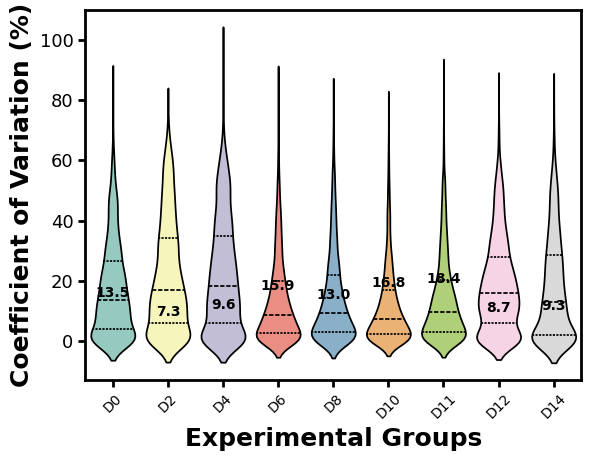

In [ ]:
#@title **Execute coefficient of variation plot**

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

file_path = 'TABLES/CVs.csv'
df = pd.read_csv(file_path)

plt.rcParams['font.family'] = 'DejaVu Sans'

def plot_data(df):
    group_names = [col for col in df.columns if col not in ['Protein name', 'Protein IDs', 'Genes']]

    melted_df = df.melt(id_vars=['Protein name', 'Protein IDs'], value_vars=group_names, var_name='Group', value_name='Value')

    median_df = melted_df.groupby('Group')['Value'].median().reset_index()
    median_df.columns = ['Group', 'Median Value']
    melted_df = melted_df.merge(median_df, on='Group')

    sns.violinplot(x='Group', y='Value', hue='Group', data=melted_df, inner='quartile', palette='Set3', edgecolor='black', legend=False)
    for i, row in median_df.iterrows():
        plt.text(i, row['Median Value'], f'{row["Median Value"]:.1f}', horizontalalignment='center', verticalalignment='bottom', fontsize=10, fontweight='bold')

    plt.ylabel('Coefficient of Variation (%)', fontsize=18, fontweight='bold')
    plt.xlabel('Experimental Groups', fontsize=18, fontweight='bold')
    plt.tick_params(axis='x', which='both', bottom=True, length=5, width=2, color='black')
    plt.tick_params(axis='y', which='both', left=True, length=5, width=2, color='black')
    plt.xticks(rotation=45, fontsize=10)
    plt.yticks(fontsize=13)

    ax1 = plt.gca()
    for spine in ax1.spines.values():
        spine.set_linewidth(2)
        spine.set_color("k")

    plt.savefig('PLOTS/CV_violin_plot.tiff', format='tiff', dpi=300, bbox_inches='tight')
    plt.show()

plot_data(df)


##**Correlation among replicates**
- Plots the distribution of the dataset
- Calculates the Spearman's rank correlation coefficient among replicates

Text(value='', description='Samples:', layout=Layout(width='auto'), placeholder='Separated by commas (up to 3)…

Button(description='Plot Data', layout=Layout(height='80px', width='auto'), style=ButtonStyle(button_color='#4…

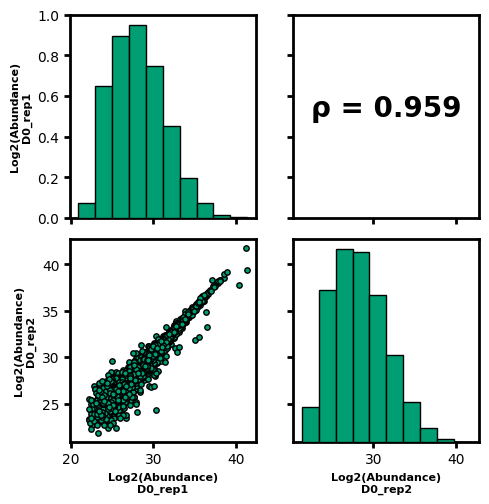

In [ ]:
#@title **Select samples for correlation plot**
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
import ipywidgets as widgets
from IPython.display import display

plt.rcParams['font.family'] = 'DejaVu Sans'

file_path = 'TABLES/melted_protein_data_samples.csv'
df = pd.read_csv(file_path)

columns_input = widgets.Text(
    value='',
    placeholder='Separated by commas (up to 3)',
    description='Samples:',
    layout=widgets.Layout(width='auto', description_width='initial'),
    style={'description_width': 'initial', 'font_size': '16px'}
)

button = widgets.Button(description="Plot Data", style={'font_weight': 'bold', 'button_color': '#4CAF50', 'font_size': '16px'}, layout=widgets.Layout(
                width='auto',
                height='80px'
            ))

def update_plot(columns):
    columns_to_plot = [col.strip() for col in columns.split(',') if col.strip() in df.columns]
    if len(columns_to_plot) > 3:
        print("Please enter up to three column names.")
        return

    # Replace zero or negative values with NaN to avoid log2 issues using DataFrame.apply
    df[columns_to_plot] = df[columns_to_plot].apply(lambda col: col.map(lambda x: np.nan if x <= 0 else x))
    df[columns_to_plot] = np.log2(df[columns_to_plot])

    def annotate_corr(x, y, **kwargs):
        valid_idx = x.notna() & y.notna()
        x_valid = x[valid_idx]
        y_valid = y[valid_idx]

        if len(x_valid) > 1 and len(y_valid) > 1:
            rho, _ = spearmanr(x_valid, y_valid)
        else:
            rho = np.nan

        ax = plt.gca()
        x_pos = (ax.get_xlim()[0] + ax.get_xlim()[1]) / 2
        y_pos = (ax.get_ylim()[0] + ax.get_ylim()[1]) / 2
        ax.annotate(f'ρ = {rho:.3f}', xy=(x_pos, y_pos), xycoords='data', ha='center', fontsize=20, fontweight='bold')

    g = sns.PairGrid(df, vars=columns_to_plot, diag_sharey=False)
    g.map_diag(plt.hist, bins=10, edgecolor='black', color='#009E73')
    g.map_lower(plt.scatter, color='#009E73', edgecolor='black', s=15)
    g.map_upper(annotate_corr)

    for ax in g.axes.flat:
        if ax.get_xlabel():
            ax.set_xlabel('Log2(Abundance)\n' + ax.get_xlabel(), fontsize=8, fontweight='bold')
        if ax.get_ylabel():
            ax.set_ylabel('Log2(Abundance)\n' + ax.get_ylabel(), fontsize=8, fontweight='bold')
        ax.tick_params(axis='x', which='both', bottom=True, length=4, width=2, color='black')
        ax.tick_params(axis='y', which='both', left=True, length=4, width=2, color='black')
        ax.spines['top'].set_color('black')
        ax.spines['bottom'].set_color('black')
        ax.spines['left'].set_color('black')
        ax.spines['right'].set_color('black')
        ax.spines['top'].set_linewidth(2)
        ax.spines['right'].set_linewidth(2)
        ax.spines['bottom'].set_linewidth(2)
        ax.spines['left'].set_linewidth(2)
        ax.spines['top'].set_visible(True)
        ax.spines['right'].set_visible(True)

    plt.savefig(f'PLOTS/correlation{columns_to_plot}.tiff', format='tiff', dpi=300, bbox_inches='tight')
    plt.show()

def on_button_click(b):
    columns = columns_input.value
    update_plot(columns)

button.on_click(on_button_click)
display(columns_input, button)


##**Number of points Across Peak**

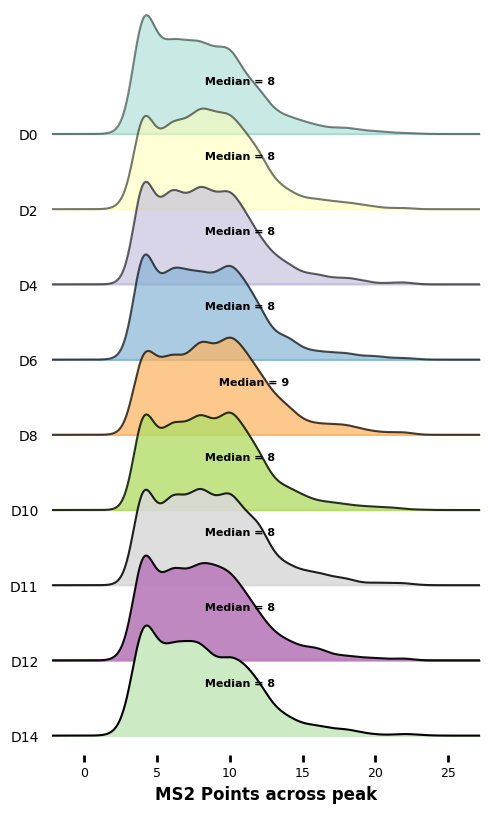

In [ ]:
#@title **Density plot: Number of MS2 points across peak**
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joypy

plt.rcParams['font.family'] = 'DejaVu Sans'
file_path = 'TABLES/points_across_peak_MS2.csv'
df = pd.read_csv(file_path)

def plot_data():
    group_names = [col for col in df.columns if col not in ['Protein name', 'Protein IDs' , 'Genes']]

    melted_df = df.melt(id_vars=['Protein name', 'Protein IDs', 'Genes'], value_vars=group_names, var_name='Group', value_name='Value')
    grouped_data = [melted_df[melted_df['Group'] == group]['Value'].values for group in group_names]
    fig, axes = joypy.joyplot(data=grouped_data, labels=group_names[:len(grouped_data)], colormap=plt.get_cmap('Set3'), fade=True, figsize=(5, 8))

    plt.xlabel('MS2 Points across peak', fontsize=12, fontweight='bold')
    plt.ylabel('Density', fontsize=18, fontweight='bold')
    plt.tick_params(axis='x', which='both', bottom=True, length=5, width=2, color='black')
    plt.tick_params(axis='y', which='both', left=True, length=5, width=2, color='black')
    plt.xticks(fontsize=9)
    plt.yticks(fontsize=15, fontweight='bold')

    for ax, group in zip(axes, group_names):
        median_value = round(df[group].median())
        ax.text(median_value, ax.get_ylim()[1] * 0.4, f' Median = {median_value}', color='black', fontsize=8, zorder=10, fontweight='bold')

    ax1 = plt.gca()
    for spine in ax1.spines.values():
        spine.set_linewidth(2)
        spine.set_color("k")

    plt.savefig('PLOTS/Density_points_across_peak_MS2.tiff', format='tiff', dpi=300, bbox_inches='tight')
    plt.show()

plot_data()

#**Peptide and protein yields**

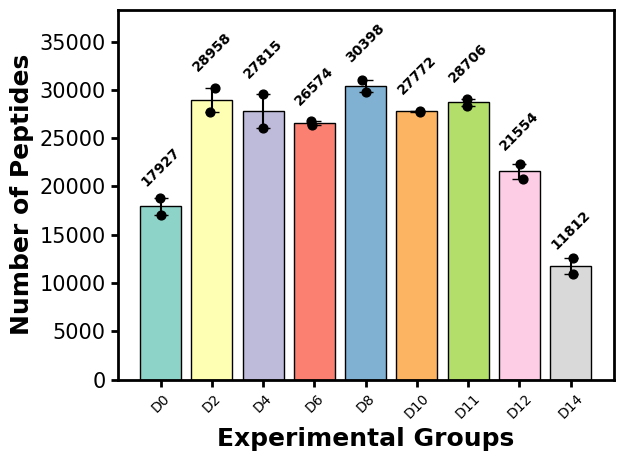

In [ ]:
#@title **Peptides: median values**
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'DejaVu Sans'

file_path = 'TABLES/peptide_counts.csv'
df = pd.read_csv(file_path)

def update_dataframe(df):
    groups = df.groupby('Experimental groups')['Number of peptides'].apply(list).to_dict()
    medians = []
    std_devs = []
    all_values = []

    ordered_groups = {group: groups[group] for group in df['Experimental groups'].unique()}

    for group_name, values in ordered_groups.items():
        medians.append(np.median(values))
        std_devs.append(np.std(values))
        all_values.append(values)

    fig, ax = plt.subplots()
    colors = sns.color_palette('Set3', len(ordered_groups))
    bars = ax.bar(ordered_groups.keys(), medians, yerr=std_devs, capsize=5, color=colors, edgecolor='black')

    for i, group in enumerate(ordered_groups.keys()):
        y = all_values[i]
        x = np.random.normal(i, 0.04, size=len(y))
        ax.scatter(x, y, edgecolor='black', facecolor='black', s=40, zorder=2)

    label_texts = []
    for bar, median, std in zip(bars, medians, std_devs):
        offset = 0.05 * median
        label_y = median + std + offset
        text = ax.text(
            bar.get_x() + bar.get_width() / 2.0,
            label_y,
            f'{median:.0f}',
            ha='center', va='bottom', fontsize=10,
            fontweight='bold', rotation=45
        )
        label_texts.append(text)

    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()

    max_label_top = max([
        text.get_window_extent(renderer=renderer).transformed(ax.transData.inverted()).y1
        for text in label_texts
    ])

    current_ylim = ax.get_ylim()
    ax.set_ylim(top=max_label_top * 1.05, bottom=current_ylim[0])

    plt.xlabel('Experimental Groups', fontsize=18, fontweight='bold')
    ax.set_ylabel('Number of Peptides', fontweight='bold', fontsize=18)
    plt.tick_params(axis='x', which='both', bottom=True, length=5, width=2, color='black')
    plt.tick_params(axis='y', which='both', left=True, length=5, width=2, color='black')
    plt.yticks(fontsize=15)
    plt.xticks(rotation=45, fontsize=10)

    for spine in ax.spines.values():
        spine.set_linewidth(2)
        spine.set_color("k")

    plt.savefig('PLOTS/Number_peptides_median.tiff', format='tiff', dpi=300, bbox_inches='tight')
    plt.show()

update_dataframe(df)


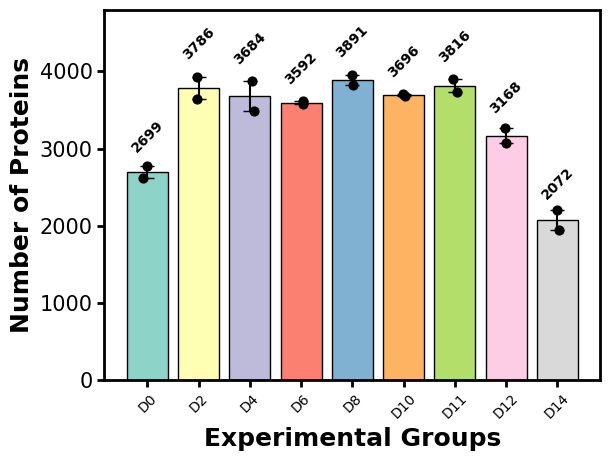

In [ ]:
#@title **Proteins: median values**
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'DejaVu Sans'

file_path = 'TABLES/protein_counts.csv'
df = pd.read_csv(file_path)

def update_dataframe(df):
    groups = df.groupby('Experimental groups')['Number of proteins'].apply(list).to_dict()
    medians = []
    std_devs = []
    all_values = []

    ordered_groups = {group: groups[group] for group in df['Experimental groups'].unique()}

    for group_name, values in ordered_groups.items():
        medians.append(np.median(values))
        std_devs.append(np.std(values))
        all_values.append(values)

    fig, ax = plt.subplots()
    colors = sns.color_palette('Set3', len(ordered_groups))
    bars = ax.bar(ordered_groups.keys(), medians, yerr=std_devs, capsize=5, color=colors, edgecolor='black')

    for i, group in enumerate(ordered_groups.keys()):
        y = all_values[i]
        x = np.random.normal(i, 0.04, size=len(y))
        ax.scatter(x, y, edgecolor='black', facecolor='black', s=40, zorder=2)

    label_texts = []
    for bar, median, std in zip(bars, medians, std_devs):
        offset = 0.05 * median
        label_y = median + std + offset
        text = ax.text(
            bar.get_x() + bar.get_width() / 2.0,
            label_y,
            f'{median:.0f}',
            ha='center', va='bottom', fontsize=10,
            fontweight='bold', rotation=45
        )
        label_texts.append(text)

    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()

    max_label_top = max([
        text.get_window_extent(renderer=renderer).transformed(ax.transData.inverted()).y1
        for text in label_texts
    ])
    current_ylim = ax.get_ylim()
    ax.set_ylim(top=max_label_top * 1.05, bottom=current_ylim[0])

    plt.xlabel('Experimental Groups', fontsize=18, fontweight='bold')
    ax.set_ylabel('Number of Proteins', fontweight='bold', fontsize=18)
    plt.tick_params(axis='x', which='both', bottom=True, length=5, width=2, color='black')
    plt.tick_params(axis='y', which='both', left=True, length=5, width=2, color='black')
    plt.yticks(fontsize=15)
    plt.xticks(rotation=45, fontsize=10)

    for spine in ax.spines.values():
        spine.set_linewidth(2)
        spine.set_color("k")

    plt.savefig('PLOTS/Number_proteins_median.tiff', format='tiff', dpi=300, bbox_inches='tight')
    plt.show()

update_dataframe(df)



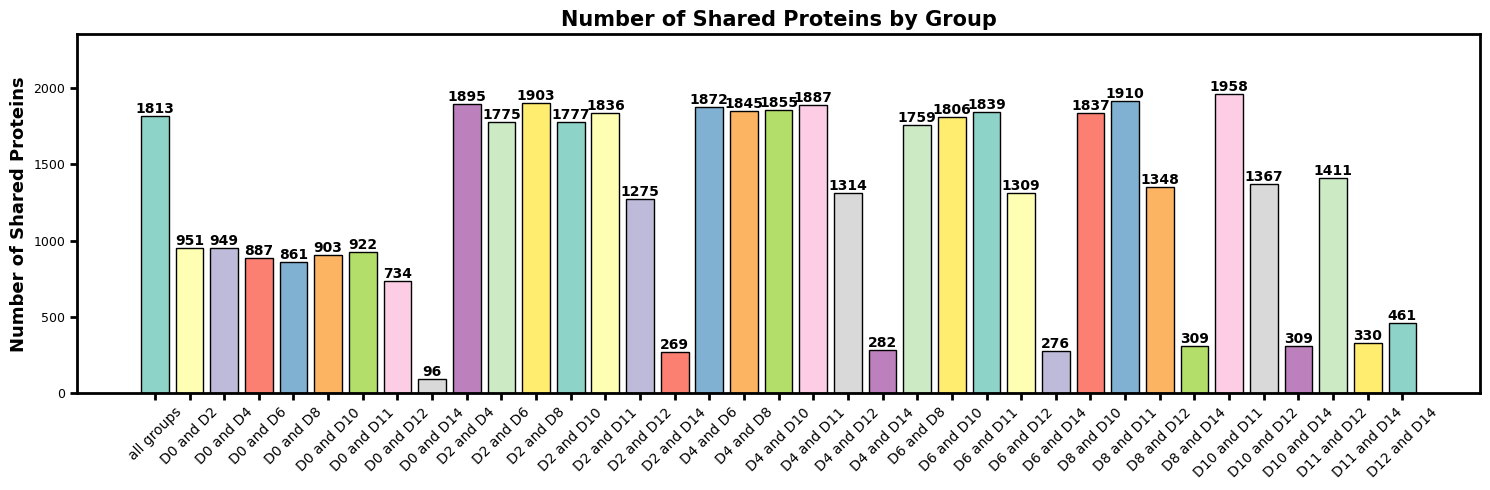

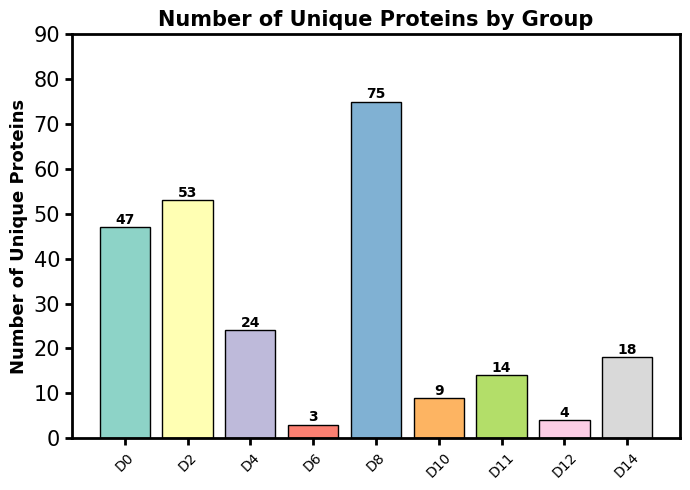

In [ ]:
#@title **Breackdown of shared and unique proteins**
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('TABLES/SHARED_UNIQUE_PROTEINS/shared_unique_proteins.csv')
shared_df = df[df['Group'].str.startswith('Shared by')].copy()
unique_df = df[df['Group'].str.startswith('Unique to')].copy()

shared_df.loc[:, 'Group'] = shared_df['Group'].str.replace('Shared by ', '', regex=False)
unique_df.loc[:, 'Group'] = unique_df['Group'].str.replace('Unique to ', '', regex=False)


plt.figure(figsize=(15, 5))
colors = sns.color_palette('Set3', len(shared_df['Group']))
bars = plt.bar(shared_df['Group'], shared_df['Number of Shared Proteins'], color=colors, edgecolor='black')
plt.ylabel('Number of Shared Proteins', fontweight='bold', fontsize=13)
plt.title('Number of Shared Proteins by Group', fontsize=15, fontweight='bold')
plt.tick_params(axis='x', which='both', bottom=True, length=5, width=2, color='black')
plt.tick_params(axis='y', which='both', left=True, length=5, width=2, color='black')
plt.yticks(fontsize=9)
plt.xticks(rotation=45, fontsize=10)
plt.tight_layout()
ax1 = plt.gca()
for spine in ax1.spines.values():
    spine.set_linewidth(2)
    spine.set_color("k")
ax1.margins(y=0.2)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.05, round(yval, 2), ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.savefig('PLOTS/Shared_proteins.tiff', format='tiff', dpi=300, bbox_inches='tight')
plt.show()


plt.figure(figsize=(7, 5))
colors = sns.color_palette('Set3', len(unique_df['Group']))
bars = plt.bar(unique_df['Group'], unique_df['Number of Unique Proteins'], color=colors, edgecolor='black')
plt.ylabel('Number of Unique Proteins', fontweight='bold', fontsize=13)
plt.title('Number of Unique Proteins by Group', fontsize=15, fontweight='bold')
plt.tick_params(axis='x', which='both', bottom=True, length=5, width=2, color='black')
plt.tick_params(axis='y', which='both', left=True, length=5, width=2, color='black')
plt.yticks(fontsize=15)
plt.xticks(rotation=45, fontsize=10)
plt.tight_layout()
ax2 = plt.gca()
for spine in ax2.spines.values():
    spine.set_linewidth(2)
    spine.set_color("k")
ax2.margins(y=0.2)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.05, round(yval, 2), ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.savefig('PLOTS/Unique_proteins.tiff', format='tiff', dpi=300, bbox_inches='tight')
plt.show()

##**Number of peptides per protein**
- Displays a density plot for the number of peptides used to calculate the relative abundance of proteins in the overall proteome. Median values are displayed for each experimental group.
- Displays the number of peptides for a given protein of interest

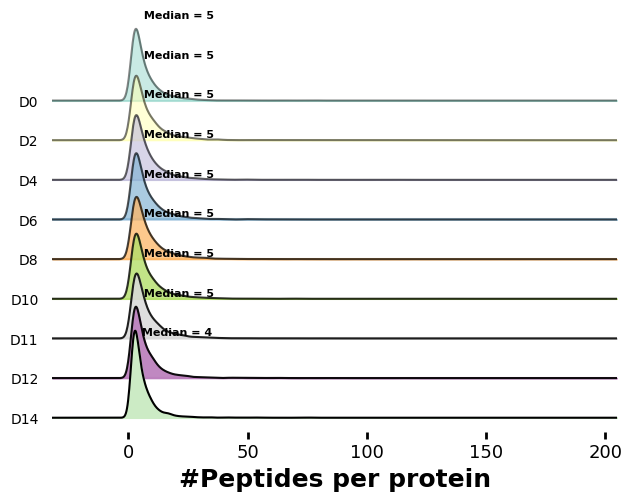

In [ ]:
#@title **Density plot**
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joypy
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)

plt.rcParams['font.family'] = 'DejaVu Sans'
file_path = 'TABLES/melted_number_peptides_per_protein_per_group.csv'
df = pd.read_csv(file_path)
df = df.drop(columns=['Genes'])

def plot_data(df):
    group_names = [col for col in df.columns if col not in ['Protein name', 'Protein IDs']]

    melted_df = df.melt(id_vars=['Protein name', 'Protein IDs'], value_vars=group_names, var_name='Group', value_name='Value')
    melted_df['Group'] = pd.Categorical(melted_df['Group'], categories=group_names, ordered=True)
    melted_df = melted_df.sort_values('Group')

    fig, axes = joypy.joyplot(data=melted_df, by='Group', column='Value', colormap=plt.get_cmap('Set3'), fade=True)

    plt.xlabel('#Peptides per protein', fontsize=18, fontweight='bold')
    plt.ylabel('Density', fontsize=18, fontweight='bold')
    plt.tick_params(axis='x', which='both', bottom=True, length=5, width=2, color='black')
    plt.tick_params(axis='y', which='both', left=True, length=5, width=2, color='black')
    plt.xticks(fontsize=13)
    plt.yticks(fontsize=15, fontweight='bold')

    for ax, group in zip(axes, group_names):
        median_value = int(df[group].median())
        ax.text(median_value, ax.get_ylim()[1] * 0.9, f' Median = {median_value}', color='black', fontsize=8, fontweight='bold')

    ax1 = plt.gca()
    for spine in ax1.spines.values():
        spine.set_linewidth(2)
        spine.set_color("k")

    plt.savefig('PLOTS/Density_peptides_per_protein.tiff', format='tiff', dpi=300, bbox_inches='tight')
    plt.show()

plot_data(df)

Dropdown(description='Search by:', layout=Layout(width='auto'), options=('Protein name', 'Genes'), style=Descr…

Text(value='', description='Name:', layout=Layout(width='auto'), placeholder='e.g., ACL6A_HUMAN or ACTL6A', st…

Button(description='Generate Plot', layout=Layout(height='80px', width='auto'), style=ButtonStyle(button_color…

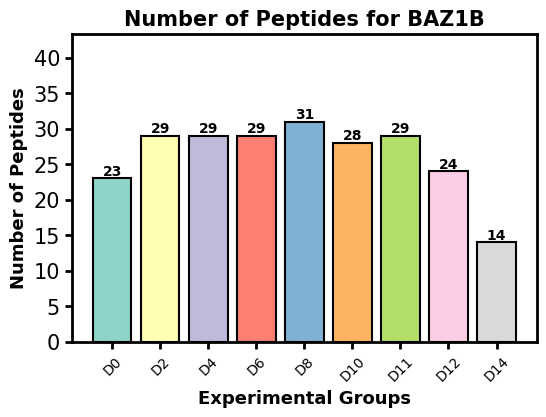

In [ ]:
#@title **Number of peptides for a given protein**
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display

df = pd.read_csv('TABLES/melted_number_peptides_per_protein_per_group.csv')
def plot_protein_or_gene(name, search_by='Protein name'):
    if search_by == 'Protein name':
        data = df[df['Protein name'] == name]
    elif search_by == 'Genes':
        data = df[df['Genes'] == name]
    else:
        print(f"Invalid search criteria: {search_by}")
        return

    if data.empty:
        print(f"No data found for {search_by}: {name}")
        return

    all_groups = df.columns[3:]
    all_groups_df = pd.DataFrame(columns=all_groups)
    all_groups_df.loc[0] = 0
    data = pd.concat([all_groups_df, data], ignore_index=True).fillna(0)
    values = data.iloc[1].reindex(all_groups, fill_value=0)

    colors = sns.color_palette("Set3", len(all_groups))

    plt.figure(figsize=(6, 4))
    bars = plt.bar(all_groups, values, edgecolor='black', color=colors, linewidth=1.5)
    plt.xlabel('Experimental Groups', fontsize=13, fontweight='bold')
    plt.ylabel('Number of Peptides', fontsize=13, fontweight='bold')
    plt.tick_params(axis='x', which='both', bottom=True, length=5, width=2, color='black')
    plt.tick_params(axis='y', which='both', left=True, length=5, width=2, color='black')
    plt.title(f'Number of Peptides for {name}', fontweight='bold', fontsize=15)
    plt.yticks(fontsize=15)
    plt.xticks(rotation=45, fontsize=10)

    for i, bar in enumerate(bars):
        yval = bar.get_height()
        if pd.isna(yval) or yval == 0:
            plt.text(bar.get_x() + bar.get_width() / 2, 0.1, 'n.d.', ha='center', va='bottom', fontsize=15, color='red', fontweight='bold')
        else:
            plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.05, int(yval), ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax1 = plt.gca()
    for spine in ax1.spines.values():
        spine.set_linewidth(2)
        spine.set_color("k")

    ax1.margins(y=0.4)
    plt.savefig(f'PLOTS/Number_peptides_for_{name}.tiff', format='tiff', dpi=300, bbox_inches='tight')
    plt.show()

search_by_dropdown = widgets.Dropdown(
    options=['Protein name', 'Genes'],
    value='Protein name',
    description='Search by:',
    layout=widgets.Layout(width='auto', description_width='initial'),
    style={'description_width': 'initial', 'font_size': '16px'}
)

name_input = widgets.Text(
    value='',
    placeholder='e.g., ACL6A_HUMAN or ACTL6A',
    description='Name:',
    layout=widgets.Layout(width='auto', description_width='initial'),
    style={'description_width': 'initial', 'font_size': '16px'}
)

button = widgets.Button(
    description="Generate Plot",
    style={'font_weight': 'bold', 'button_color': '#4CAF50', 'font_size': '16px'},
    layout=widgets.Layout(width='auto', height='80px')
)

def on_button_click(b):
    name = name_input.value
    search_by = search_by_dropdown.value
    plot_protein_or_gene(name, search_by)

button.on_click(on_button_click)

display(search_by_dropdown)
display(name_input)
display(button)

#**Exploratory analysis**

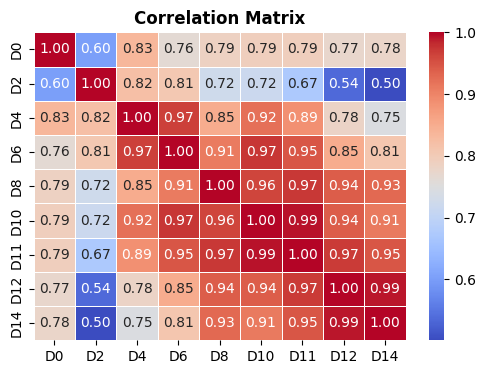

In [ ]:
#@title **Correlation Matrix**
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.exceptions import ConvergenceWarning
import warnings


warnings.filterwarnings("ignore", category=ConvergenceWarning)

file_path = 'TABLES/median_abundance.csv'
data = pd.read_csv(file_path)

data_values = data.iloc[:, 3:]
imputer = IterativeImputer(max_iter=10, random_state=0)
data_values_imputed = imputer.fit_transform(data_values)

correlation_matrix = pd.DataFrame(data_values_imputed, columns=data.columns[3:]).corr()

plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix', fontsize=12, fontweight='bold')
plt.savefig('PLOTS/Correlation_Matrix.tiff', format='tiff', dpi=300, bbox_inches='tight')
plt.show()


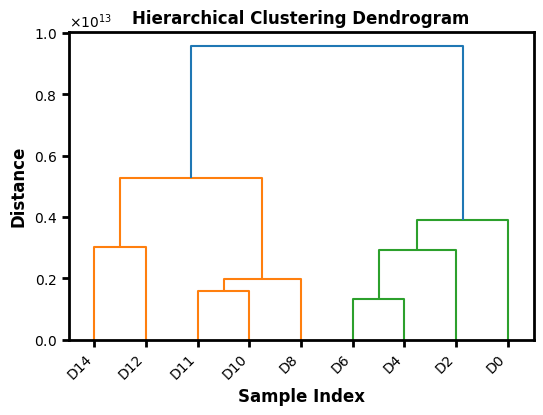

In [ ]:
#@title **Hierarchical Clustering Dendrogram**
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.exceptions import ConvergenceWarning
from scipy.cluster.hierarchy import dendrogram, linkage
import os
import warnings

warnings.filterwarnings("ignore", category=ConvergenceWarning)
os.makedirs('PLOTS', exist_ok=True)
file_path = 'TABLES/median_abundance.csv'
data = pd.read_csv(file_path)

data_values = data.iloc[:, 3:]
imputer = IterativeImputer()
data_values_imputed = imputer.fit_transform(data_values)

linked = linkage(data_values_imputed.T, method='ward')
plt.figure(figsize=(6, 4))
dendrogram(linked,
           orientation='top',
           labels=data.columns[3:],
           distance_sort='descending',
           show_leaf_counts=True)

plt.title('Hierarchical Clustering Dendrogram', fontsize=12, fontweight='bold')
plt.xlabel('Sample Index', fontsize=12, fontweight='bold')
plt.ylabel('Distance', fontsize=12, fontweight='bold')
plt.tick_params(axis='x', which='both', bottom=True, length=5, width=2, color='black')
plt.tick_params(axis='y', which='both', left=True, length=5, width=2, color='black')
plt.yticks(fontsize=10)
plt.xticks(fontsize=10, rotation=45, ha='right')
ax = plt.gca()
ax.grid(False)
for spine in ax.spines.values():
    spine.set_linewidth(2)
    spine.set_color("k")

ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))

plt.savefig('PLOTS/Hierarchical_Clustering_Dendrogram.tiff', format='tiff', dpi=300, bbox_inches='tight')
plt.show()



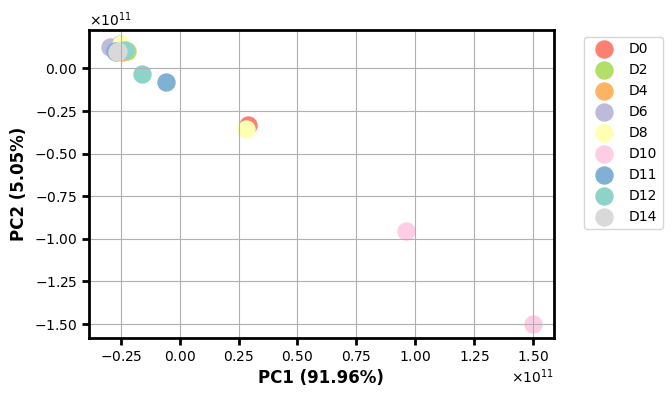

In [ ]:
#@title **Principal components analysis (PCA)**
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.decomposition import PCA
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.exceptions import ConvergenceWarning
import seaborn as sns
import warnings

warnings.filterwarnings("ignore", category=ConvergenceWarning)
os.makedirs('PLOTS', exist_ok=True)

df = pd.read_csv('TABLES/Quantitative_parameters.csv')

pivot_df = df.pivot_table(
    index=['Protein name', 'Protein IDs', 'Genes'],
    columns=['Experimental groups', 'Sample'],
    values='Protein Abundance Transition Summed',
    aggfunc='first',
    sort=False
)

pivot_df.columns = [f'{col[0]}' for col in pivot_df.columns]
pivot_df.reset_index(inplace=True)
data_values = pivot_df.iloc[:, 3:]

imputer = IterativeImputer()
imputed_data = imputer.fit_transform(data_values)

pca = PCA(n_components=2)
principal_components = pca.fit_transform(imputed_data)
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
explained_variance_ratio = pca.explained_variance_ratio_

plt.figure(figsize=(6, 4))
sample_names = pivot_df.columns[3:]
unique_sample_names = list(set(sample_names))
palette = sns.color_palette("Set3", len(unique_sample_names))

for i, sample in enumerate(sample_names):
    unique_sample_index = unique_sample_names.index(sample)
    plt.scatter(
        pca_df['PC1'][i], pca_df['PC2'][i],
        label=sample if sample not in plt.gca().get_legend_handles_labels()[1] else "",
        color=palette[unique_sample_index],
        s=150
    )

plt.xlabel(f'PC1 ({explained_variance_ratio[0]*100:.2f}%)', fontsize=12, fontweight='bold')
plt.ylabel(f'PC2 ({explained_variance_ratio[1]*100:.2f}%)', fontsize=12, fontweight='bold')
plt.tick_params(axis='x', which='both', bottom=True, length=5, width=2, color='black')
plt.tick_params(axis='y', which='both', left=True, length=5, width=2, color='black')
plt.yticks(fontsize=10)
plt.xticks(fontsize=10)
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))

ax = plt.gca()
ax.grid(False)
for spine in ax.spines.values():
    spine.set_linewidth(2)
    spine.set_color("k")
ax.xaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
plt.grid(True)
plt.savefig('PLOTS/PCA.tiff', format='tiff', dpi=300, bbox_inches='tight')
plt.show()


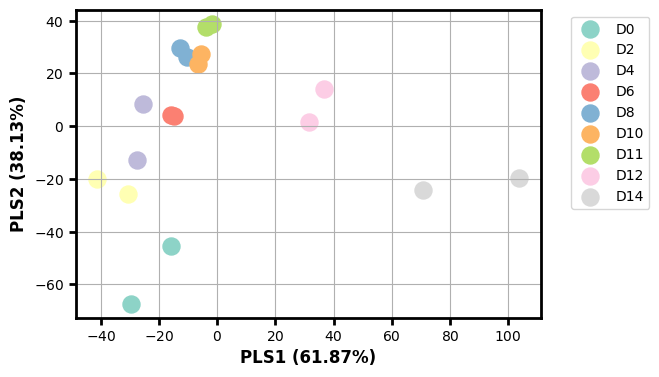

In [ ]:
#@title **Partial Least Squares Discriminant Analysis (PLS-DA)**
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.cross_decomposition import PLSRegression
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.exceptions import ConvergenceWarning
import seaborn as sns
import warnings

warnings.filterwarnings("ignore", category=ConvergenceWarning)
os.makedirs('PLOTS', exist_ok=True)

df = pd.read_csv('TABLES/Quantitative_parameters.csv')
pivot_df = df.pivot_table(
    index=['Protein name', 'Protein IDs', 'Genes'],
    columns=['Experimental groups', 'Sample'],
    values='Protein Abundance Transition Summed',
    aggfunc='first',
    sort=False
)


pivot_df.columns = [f'{col[0]}' for col in pivot_df.columns]
pivot_df.reset_index(inplace=True)

data_values = pivot_df.iloc[:, 3:]
imputer = IterativeImputer()
imputed_data = imputer.fit_transform(data_values)

imputed_data = imputed_data.T
experimental_groups = [col.split('_')[0] for col in pivot_df.columns[3:]]
group_labels, group_names = pd.factorize(pd.Series(experimental_groups))

plsda = PLSRegression(n_components=2)
plsda.fit(imputed_data, group_labels)
plsda_components = plsda.transform(imputed_data)

X_scores = plsda.x_scores_
explained_var = (X_scores.var(axis=0) / X_scores.var(axis=0).sum()) * 100

plsda_df = pd.DataFrame(data=plsda_components, columns=['PLS1', 'PLS2'])

plt.figure(figsize=(6, 4))
unique_groups = list(dict.fromkeys(experimental_groups))  # preserve order
palette = sns.color_palette("Set3", len(unique_groups))

for i, (x, y) in enumerate(zip(plsda_df['PLS1'], plsda_df['PLS2'])):
    group = experimental_groups[i]
    color = palette[unique_groups.index(group)]
    plt.scatter(x, y, label=group if group not in plt.gca().get_legend_handles_labels()[1] else "", color=color, s=150)

plt.xlabel(f'PLS1 ({explained_var[0]:.2f}%)', fontsize=12, fontweight='bold')
plt.ylabel(f'PLS2 ({explained_var[1]:.2f}%)', fontsize=12, fontweight='bold')
plt.tick_params(axis='x', which='both', bottom=True, length=5, width=2, color='black')
plt.tick_params(axis='y', which='both', left=True, length=5, width=2, color='black')
plt.yticks(fontsize=10)
plt.xticks(fontsize=10)
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))

ax = plt.gca()
ax.grid(False)
for spine in ax.spines.values():
    spine.set_linewidth(2)
    spine.set_color("k")
ax.xaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
plt.grid(True)
plt.savefig('PLOTS/PLSDA.tiff', format='tiff', dpi=300, bbox_inches='tight')
plt.show()


Dropdown(description='Search by:', layout=Layout(width='auto'), options=('Protein name', 'Genes'), style=Descr…

Dropdown(description='Top features:', index=1, layout=Layout(width='auto'), options=(3, 5, 10), style=Descript…

Button(description='Display Plot', layout=Layout(height='40px', width='auto'), style=ButtonStyle(button_color=…

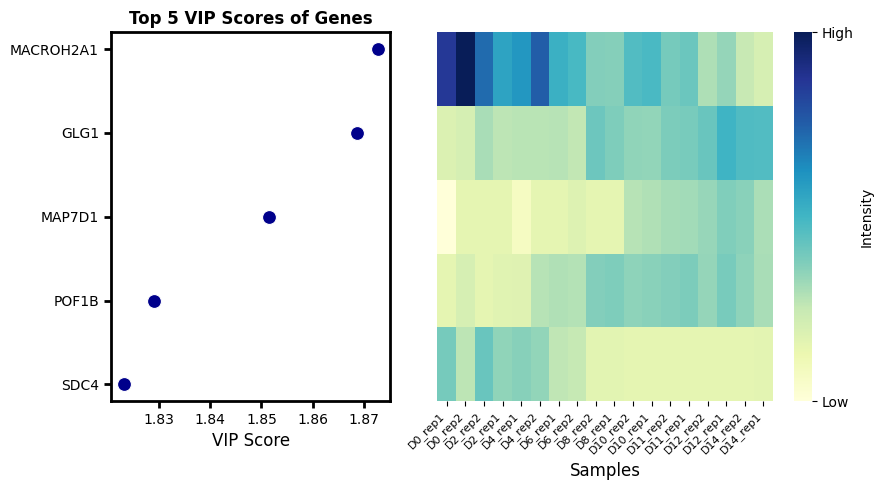

In [ ]:
#@title **VIP Scores Highlighting Proteins/Genes Governing Grouping in PLS-DA Plot**

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.cross_decomposition import PLSRegression
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.exceptions import ConvergenceWarning
import ipywidgets as widgets
from IPython.display import display

warnings.filterwarnings("ignore", category=ConvergenceWarning)
os.makedirs('PLOTS', exist_ok=True)

df = pd.read_csv('TABLES/Quantitative_parameters.csv')

pivot_df = df.pivot_table(
    index=['Protein name', 'Protein IDs', 'Genes'],
    columns=['Experimental groups', 'Sample'],
    values='Protein Abundance Transition Summed',
    aggfunc='first',
    sort=False
)

pivot_df.columns = [f'{col[1]}' for col in pivot_df.columns]
pivot_df.reset_index(inplace=True)
data_values = pivot_df.iloc[:, 3:]
imputer = IterativeImputer()
imputed_data = imputer.fit_transform(data_values)
imputed_data = imputed_data.T

sample_names = data_values.columns.tolist()
group_labels = np.arange(imputed_data.shape[0])


plsda = PLSRegression(n_components=2)
plsda.fit(imputed_data, group_labels)

T = plsda.x_scores_
W = plsda.x_weights_
Q = plsda.y_loadings_

p = imputed_data.shape[1]
h = plsda.n_components
s = np.diag(T.T @ T @ Q.T @ Q)
vip_scores = np.zeros((p,))
for i in range(p):
    weight = np.array([(W[i, j] / np.linalg.norm(W[:, j]))**2 for j in range(h)])
    vip_scores[i] = np.sqrt(p * (s @ weight) / s.sum())

vip_df = pd.DataFrame({
    'Protein name': pivot_df['Protein name'],
    'Genes': pivot_df['Genes'],
    'VIP Score': vip_scores
})

search_by_dropdown = widgets.Dropdown(
    options=['Protein name', 'Genes'],
    value='Protein name',
    description='Search by:',
    layout=widgets.Layout(width='auto', description_width='initial'),
    style={'description_width': 'initial', 'font_size': '16px'}
)

top_features_dropdown = widgets.Dropdown(
    options=[3, 5, 10],
    value=5,
    description='Top features:',
    layout=widgets.Layout(width='auto', description_width='initial'),
    style={'description_width': 'initial', 'font_size': '16px'}
)

plot_button = widgets.Button(
    description="Display Plot",
    style={'font_weight': 'bold', 'button_color': '#4CAF50', 'font_size': '16px'},
    layout=widgets.Layout(width='auto', height='40px')
)

def plot_vip_scores_and_heatmap(search_by, top_n):
    top_vip_df = vip_df.nlargest(top_n, 'VIP Score')
    top_indices = top_vip_df.index
    top_features_data = imputed_data[:, top_indices]

    fig, ax = plt.subplots(1, 2, figsize=(9, 5), gridspec_kw={'width_ratios': [1, 1.5]})

    sns.scatterplot(x='VIP Score', y=search_by, data=top_vip_df, s=100, color='darkblue', ax=ax[0])
    ax[0].set_title(f'Top {top_n} VIP Scores of {search_by}', fontsize=12, fontweight='bold')
    ax[0].set_xlabel('VIP Score', fontsize=12)
    ax[0].set_ylabel('')

    for spine in ax[0].spines.values():
        spine.set_linewidth(2)
        spine.set_color("k")
    ax[0].tick_params(axis='x', which='both', bottom=True, length=5, width=2, color='black')
    ax[0].tick_params(axis='y', which='both', left=True, length=5, width=2, color='black')

    sns.heatmap(top_features_data.T, cmap='YlGnBu', ax=ax[1], cbar_kws={'label': 'Intensity'},
                xticklabels=sample_names, yticklabels=False)
    ax[1].set_xticklabels(sample_names, rotation=45, ha='right', fontsize=8)
    ax[1].set_xlabel('Samples', fontsize=12)
    ax[1].set_ylabel('')

    cbar = ax[1].collections[0].colorbar
    cbar.set_ticks([top_features_data.min(), top_features_data.max()])
    cbar.set_ticklabels(['Low', 'High'])

    plt.tight_layout()
    plt.savefig('PLOTS/VIP_Heatmap.tiff', format='tiff', dpi=300)
    plt.show()

display(search_by_dropdown, top_features_dropdown, plot_button)
def on_plot_button_clicked(b):
    plot_vip_scores_and_heatmap(search_by_dropdown.value, top_features_dropdown.value)

plot_button.on_click(on_plot_button_clicked)



#**Protein abundance**

##**Protein Ranking**

Dropdown(description='Search by:', layout=Layout(width='auto'), options=('Protein name', 'Genes'), style=Descr…

Dropdown(description='Experimental Groups:', options=('D0', 'D2', 'D4', 'D6', 'D8', 'D10', 'D11', 'D12', 'D14'…

Button(description='Display Plot', layout=Layout(height='40px', width='auto'), style=ButtonStyle(button_color=…

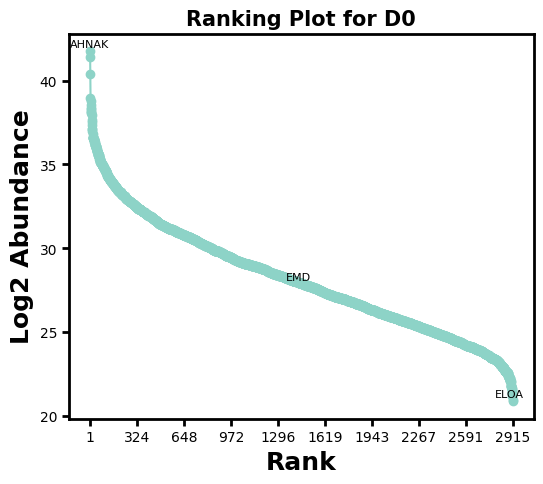

Ranking report was saved as: TABLES/Protein_Ranking_D0.csv


In [ ]:
#@title **Select experimental group**
#@markdown - Proteins are ranked based on their relative protein abundances
#@markdown - Names of the proteins with highest, medium, and lowest abundances are depicted in the plot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
import seaborn as sns
from adjustText import adjust_text

plt.rcParams['font.family'] = 'DejaVu Sans'
data = pd.read_csv('TABLES/median_abundance.csv', delimiter=',')

data_melted = data.melt(id_vars=['Protein name', 'Genes'], var_name='Experimental groups', value_name='Median Abundance')
data_melted['Median Abundance'] = pd.to_numeric(data_melted['Median Abundance'], errors='coerce')
data_melted = data_melted.dropna(subset=['Median Abundance'])

group_dropdown = widgets.Dropdown(
    options=data_melted['Experimental groups'].unique().tolist(),
    description='Experimental Groups:',
    style={'description_width': 'initial'}
)

search_by_dropdown = widgets.Dropdown(
    options=['Protein name', 'Genes'],
    value='Protein name',
    description='Search by:',
    layout=widgets.Layout(width='auto', description_width='initial'),
    style={'description_width': 'initial', 'font_size': '16px'}
)

plot_button = widgets.Button(
    description="Display Plot",
    style={'font_weight': 'bold', 'button_color': '#4CAF50', 'font_size': '16px'},
    layout=widgets.Layout(width='auto', height='40px')
)

def plot_data(group, search_by):
    filtered_data = data_melted[data_melted['Experimental groups'] == group].copy()
    filtered_data.loc[filtered_data['Median Abundance'] == 0, 'Median Abundance'] = np.nan
    filtered_data.dropna(subset=['Median Abundance'], inplace=True)

    filtered_data.loc[:, 'Log2 Abundance'] = np.log2(filtered_data['Median Abundance'])
    filtered_data = filtered_data.sort_values(by='Log2 Abundance', ascending=False)

    # Select max, median, and min proteins/genes
    max_protein = filtered_data.iloc[0]
    median_protein = filtered_data.iloc[len(filtered_data) // 2]
    min_protein = filtered_data.iloc[-1]

    selected_proteins = pd.DataFrame([max_protein, median_protein, min_protein])

    filtered_data['Rank'] = range(1, len(filtered_data) + 1)
    selected_proteins['Rank'] = selected_proteins.apply(lambda row: filtered_data[filtered_data[search_by] == row[search_by]]['Rank'].values[0], axis=1)

    colors = sns.color_palette("Set3", len(filtered_data))
    plt.figure(figsize=(6, 5))
    plt.plot(filtered_data['Rank'], filtered_data['Log2 Abundance'], marker='o', color=colors[0])

    texts = []
    for i in range(len(selected_proteins)):
        texts.append(plt.text(selected_proteins.iloc[i]['Rank'], selected_proteins.iloc[i]['Log2 Abundance'],
                              selected_proteins.iloc[i][search_by], fontsize=8, ha='center'))

    adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray'))

    plt.xlabel('Rank', fontweight='bold', fontsize=18)
    plt.ylabel('Log2 Abundance', fontweight='bold', fontsize=18)
    plt.title(f'Ranking Plot for {group}', fontweight='bold', fontsize=15)

    plt.xticks(ticks=np.linspace(1, len(filtered_data), num=10, dtype=int))

    plt.tick_params(axis='x', which='both', bottom=True, length=5, width=2, color='black')
    plt.tick_params(axis='y', which='both', left=True, length=5, width=2, color='black')

    ax = plt.gca()
    ax.grid(False)

    ax1 = plt.gca()
    for spine in ax1.spines.values():
        spine.set_linewidth(2)
        spine.set_color("k")

    plt.savefig(f'PLOTS/Protein_ranking_plot_{group}.tiff', format='tiff', dpi=300)
    plt.show()

    all_proteins_ranked = filtered_data[['Protein name', 'Genes', 'Experimental groups', 'Median Abundance', 'Log2 Abundance', 'Rank']]
    all_proteins_ranked.to_csv(f'TABLES/Protein_Ranking_{group}.csv', index=False, sep=',')

    print(f"Ranking report was saved as: TABLES/Protein_Ranking_{group}.csv")

def on_button_click(b):
    plot_data(group_dropdown.value, search_by_dropdown.value)

plot_button.on_click(on_button_click)
display(search_by_dropdown, group_dropdown, plot_button)

##**Comparison of proteome abundances among selected groups**

Dropdown(description='Group 1:', options=('D0', 'D2', 'D4', 'D6', 'D8', 'D10', 'D11', 'D12', 'D14'), style=Des…

Dropdown(description='Group 2:', options=('D0', 'D2', 'D4', 'D6', 'D8', 'D10', 'D11', 'D12', 'D14'), style=Des…

Dropdown(description='P-value threshold:', options=(0.05, 0.01, 0.005, 0.001), style=DescriptionStyle(descript…

Dropdown(description='FC threshold (±):', options=(0.5, 1, 1.5, 2, 3, 4, 5, 6, 7, 8, 9, 10), style=Description…

Dropdown(description='Search by:', layout=Layout(width='auto'), options=('Protein name', 'Genes'), style=Descr…

Text(value='', description='Name:', layout=Layout(width='auto'), placeholder='Enter one or more protein names …

Button(description='Display Plot', layout=Layout(height='40px', width='auto'), style=ButtonStyle(button_color=…

Report was saved as: TABLES/VOLCANO_PLOT_VALUES/D0 vs D12_Total_proteins.csv
Report was saved as: TABLES/VOLCANO_PLOT_VALUES/D0 vs D12_Downregulated.csv
Report was saved as: TABLES/VOLCANO_PLOT_VALUES/D0 vs D12_Upregulated.csv


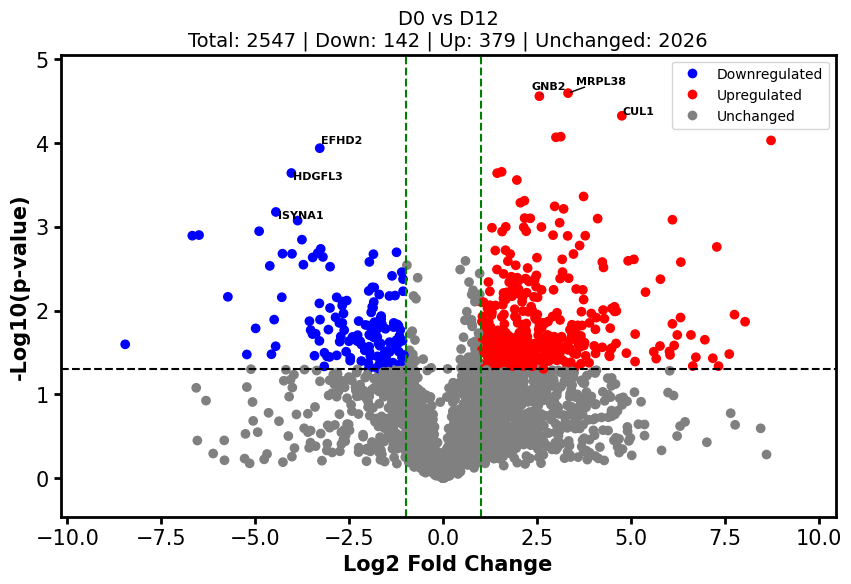

In [ ]:
#@title **Volcano Plot**
#@markdown - Select the two experimental groups you want to compare.
#@markdown - This process may take 1–2 minutes. **Please be patient.**
#@markdown - OPTIONAL – You can highlight specific proteins of interest by typing their names or gene symbols. Otherwise, leave this cell empty and click on 'Display Plot'.

import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ttest_ind
import warnings
import ipywidgets as widgets
from IPython.display import display
from adjustText import adjust_text

warnings.filterwarnings("ignore", category=RuntimeWarning, message="invalid value encountered in scalar divide")
warnings.filterwarnings("ignore", category=RuntimeWarning, message=".*Precision loss occurred.*")

output_dir = 'TABLES/VOLCANO_PLOT_VALUES'
os.makedirs(output_dir, exist_ok=True)

df = pd.read_csv('TABLES/Quantitative_parameters.csv')
unique_groups = df['Experimental groups'].unique()

group1_dropdown = widgets.Dropdown(
    options=unique_groups,
    description='Group 1:',
    style={'description_width': 'initial'}
)
group2_dropdown = widgets.Dropdown(
    options=unique_groups,
    description='Group 2:',
    style={'description_width': 'initial'}
)
p_value_threshold_dropdown = widgets.Dropdown(
    options=[0.05, 0.01, 0.005, 0.001],
    description='P-value threshold:',
    style={'description_width': 'initial'}
)
fc_threshold_dropdown = widgets.Dropdown(
    options=[0.5, 1, 1.5, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    description='FC threshold (±):',
    style={'description_width': 'initial'}
)
search_criteria = widgets.Dropdown(
    options=['Protein name', 'Genes'],
    value='Protein name',
    description='Search by:',
    layout=widgets.Layout(width='auto', description_width='initial'),
    style={'description_width': 'initial'}
)
group_names_input = widgets.Text(
    value='',
    placeholder='Enter one or more protein names or genes, separated by commas.',
    description='Name:',
    layout=widgets.Layout(width='auto', description_width='initial'),
    style={'description_width': 'initial'}
)
plot_button = widgets.Button(
    description="Display Plot",
    style={'font_weight': 'bold', 'button_color': '#4CAF50', 'font_size': '16px'},
    layout=widgets.Layout(width='auto', height='40px')
)

def display_plot(b):
    group1 = group1_dropdown.value
    group2 = group2_dropdown.value
    p_value_threshold = p_value_threshold_dropdown.value
    fc_threshold = fc_threshold_dropdown.value
    search_by = search_criteria.value
    highlight_names = [p.strip() for p in group_names_input.value.split(',') if p.strip()]

    group1_data = df[df['Experimental groups'] == group1]
    group2_data = df[df['Experimental groups'] == group2]

    proteins = df['Protein name'].unique()

    log2_fold_changes = []
    p_values = []
    valid_proteins = []
    valid_protein_ids = []
    valid_genes = []
    differential_expression_analysis = []

    upregulated_count = 0
    downregulated_count = 0
    unchanged_count = 0

    for protein in proteins:
        group1_values = group1_data[group1_data['Protein name'] == protein]['Protein Abundance Transition Summed'].dropna()
        group2_values = group2_data[group2_data['Protein name'] == protein]['Protein Abundance Transition Summed'].dropna()

        group1_values = group1_values[group1_values > 0]
        group2_values = group2_values[group2_values > 0]

        if len(group1_values) > 0 and len(group2_values) > 0:
            t_stat, p_val = ttest_ind(group1_values, group2_values)
            g1_mean = group1_values.mean()
            g2_mean = group2_values.mean()

            log2_fc = np.log2(g2_mean / g1_mean)
            log2_fold_changes.append(log2_fc)
            p_values.append(p_val)
            valid_proteins.append(protein)
            valid_protein_ids.append(df[df['Protein name'] == protein]['Protein IDs'].values[0])
            valid_genes.append(df[df['Protein name'] == protein]['Genes'].values[0])

            if (log2_fc < -fc_threshold or log2_fc > fc_threshold) and p_val <= p_value_threshold:
                if log2_fc < 0:
                    downregulated_count += 1
                    differential_expression_analysis.append('Downregulated')
                else:
                    upregulated_count += 1
                    differential_expression_analysis.append('Upregulated')
            else:
                unchanged_count += 1
                differential_expression_analysis.append('Unchanged')

    volcano_data = pd.DataFrame({
        'Comparison': [f'{group1} vs {group2}'] * len(valid_proteins),
        'Protein name': valid_proteins,
        'Protein IDs': valid_protein_ids,
        'Genes': valid_genes,
        '[-Log10(P-value)]': -np.log10(p_values),
        'Log2 Fold Change': log2_fold_changes,
        'Differential expression analysis': differential_expression_analysis
    })

    volcano_data.dropna(inplace=True)

    downregulated_data = volcano_data[volcano_data['Differential expression analysis'] == 'Downregulated']
    upregulated_data = volcano_data[volcano_data['Differential expression analysis'] == 'Upregulated']

    downregulated_data.to_csv(f'{output_dir}/{group1} vs {group2}_Downregulated.csv', index=False)
    upregulated_data.to_csv(f'{output_dir}/{group1} vs {group2}_Upregulated.csv', index=False)
    volcano_data.to_csv(f'{output_dir}/{group1} vs {group2}_Total_proteins.csv', index=False)

    print(f"Report was saved as: {output_dir}/{group1} vs {group2}_Total_proteins.csv")
    print(f"Report was saved as: {output_dir}/{group1} vs {group2}_Downregulated.csv")
    print(f"Report was saved as: {output_dir}/{group1} vs {group2}_Upregulated.csv")

    total_proteins_count = len(valid_proteins)

    if not volcano_data.empty:
        plt.figure(figsize=(10, 6))
        colors = ['red' if x == 'Upregulated' else 'blue' if x == 'Downregulated' else 'gray' for x in volcano_data['Differential expression analysis']]
        plt.scatter(volcano_data['Log2 Fold Change'], volcano_data['[-Log10(P-value)]'], c=colors)

        ax1 = plt.gca()
        ax1.margins(x=0.1, y=0.1)

        plt.xlabel('Log2 Fold Change', fontweight='bold', fontsize=15)
        plt.ylabel('-Log10(p-value)', fontweight='bold', fontsize=15)
        plt.title(f'{group1} vs {group2}\nTotal: {total_proteins_count} | Down: {downregulated_count} | Up: {upregulated_count} | Unchanged: {unchanged_count}', fontsize=14)

        plt.axhline(y=-np.log10(p_value_threshold), color='black', linestyle='--', label=f'p-value threshold ({p_value_threshold})')
        plt.axvline(x=fc_threshold, color='green', linestyle='--', label=f'Fold change threshold (±{fc_threshold})')
        plt.axvline(x=-fc_threshold, color='green', linestyle='--')

        plt.tick_params(axis='x', which='both', bottom=True, length=5, width=2, color='black')
        plt.tick_params(axis='y', which='both', left=True, length=5, width=2, color='black')

        plt.xticks(fontsize=15)
        plt.yticks(fontsize=15)

        for spine in ax1.spines.values():
            spine.set_linewidth(2)
            spine.set_color("k")

        from matplotlib.lines import Line2D
        legend_elements = [
            Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=8, label='Downregulated'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='Upregulated'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=8, label='Unchanged')
        ]
        plt.legend(handles=legend_elements)

        texts = []
        for i in range(len(volcano_data)):
            if volcano_data['Differential expression analysis'].iloc[i] in ['Upregulated', 'Downregulated']:
                label = volcano_data[search_by].iloc[i]
                if label in highlight_names or not highlight_names:
                    texts.append(plt.text(volcano_data['Log2 Fold Change'].iloc[i], volcano_data['[-Log10(P-value)]'].iloc[i],
                                          label, fontsize=8, fontweight='bold'))

        adjust_text(texts, arrowprops=dict(arrowstyle='-', color='black'))

        os.makedirs('PLOTS', exist_ok=True)
        plt.savefig(f'PLOTS/{group1} vs {group2}_volcano_plot.tiff', format='tiff', dpi=300, bbox_inches='tight')
        plt.show()

plot_button.on_click(display_plot)
display(
    group1_dropdown,
    group2_dropdown,
    p_value_threshold_dropdown,
    fc_threshold_dropdown,
    search_criteria,
    group_names_input,
    plot_button
)


##**Abundance of a specific protein**

Dropdown(description='Search by:', layout=Layout(width='300px'), options=('Protein name', 'Genes'), style=Desc…

Dropdown(description='Target:', layout=Layout(width='300px'), options=('1433B_HUMAN', '1433E_HUMAN', '1433F_HU…

Button(description='Generate Plot', layout=Layout(height='80px', width='300px'), style=ButtonStyle(button_colo…

Output()

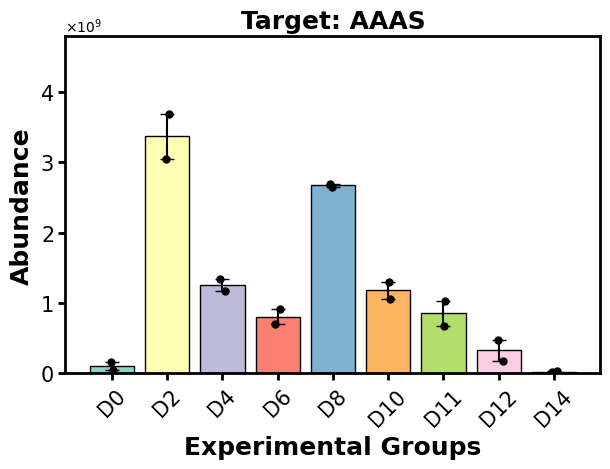

In [ ]:
#@title **Bar plot with no stats**
import pandas as pd
import numpy as np
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from IPython.display import display
import ipywidgets as widgets
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

search_criteria = widgets.Dropdown(
    options=['Protein name', 'Genes'],
    value='Protein name',
    description='Search by:',
    layout=widgets.Layout(width='300px'),
    style={'description_width': 'initial', 'font_size': '16px'}
)

target_selector = widgets.Dropdown(
    options=[],
    description='Target:',
    layout=widgets.Layout(width='300px'),
    style={'description_width': 'initial', 'font_size': '16px'}
)

button = widgets.Button(
    description="Generate Plot",
    style={'font_weight': 'bold', 'button_color': '#4CAF50', 'font_size': '16px'},
    layout=widgets.Layout(width='300px', height='80px')
)

output = widgets.Output()

def update_targets(*args):
    file_path = 'TABLES/Quantitative_parameters.csv'
    df = pd.read_csv(file_path)
    col = search_criteria.value
    target_selector.options = sorted(df[col].dropna().unique().tolist())

search_criteria.observe(update_targets, names='value')
update_targets()

def update_dataframe(name, search_by):
    file_path = 'TABLES/Quantitative_parameters.csv'
    df = pd.read_csv(file_path)

    if search_by == 'Protein name':
        df_filtered = df[df['Protein name'].str.contains(name, case=False, na=False)]
    elif search_by == 'Genes':
        df_filtered = df[df['Genes'].str.contains(name, case=False, na=False)]
    else:
        print(f"Invalid search criteria: {search_by}")
        return

    if df_filtered.empty:
        print(f"No data found for {search_by}: {name}")
        return

    df_filtered = df_filtered.drop_duplicates(subset=['Protein Abundance Transition Summed'])
    groups = df_filtered.groupby('Experimental groups')['Protein Abundance Transition Summed'].apply(list).to_dict()

    medians = []
    std_devs = []
    all_values = []

    all_groups = df['Experimental groups'].unique().tolist()

    for group_name in all_groups:
        values = groups.get(group_name, [])
        if len(values) > 0:
            medians.append(np.median(values))
            std_devs.append(np.std(values))
            all_values.append(values)
        else:
            medians.append(0)
            std_devs.append(0)
            all_values.append([])

    fig, ax = plt.subplots()
    colors = sns.color_palette('Set3', len(all_groups))

    bars = ax.bar(all_groups, medians, yerr=std_devs, capsize=5, color=colors, edgecolor='black')

    for i, group in enumerate(all_groups):
        if len(all_values[i]) == 0:
            ax.text(i, 0.5, 'n.d.', ha='center', va='bottom', fontsize=15, color='red', fontweight='bold')

    for i, group in enumerate(all_groups):
        if len(all_values[i]) > 0:
            y_values = all_values[i]
            x_values = np.random.normal(i, 0.04, size=len(y_values))
            ax.plot(x_values, y_values, 'ko', markersize=5)

    ax.set_title(f'Target: {name}', fontweight='bold', fontsize=18)
    plt.xlabel('Experimental Groups', fontsize=18, fontweight='bold')
    ax.set_ylabel('Abundance', fontweight='bold', fontsize=18)
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
    plt.tick_params(axis='x', which='both', bottom=True, length=5, width=2, color='black')
    plt.tick_params(axis='y', which='both', left=True, length=5, width=2, color='black')
    plt.yticks(fontsize=15)
    plt.xticks(rotation=45, fontsize=15)
    plt.tight_layout()

    for spine in ax.spines.values():
        spine.set_linewidth(2)
        spine.set_color("k")

    ax.margins(y=0.3)
    plt.savefig(f'PLOTS/Abundance_selected_protein_{name}.tiff', format='tiff', dpi=300, bbox_inches='tight')
    plt.show()

button.on_click(lambda b: update_dataframe(target_selector.value, search_criteria.value))
display(search_criteria, target_selector, button, output)


In [ ]:
#@title **Bar plot with t-test**
#@markdown - Data represent medians ± SD among replicates of a given experimental group
#@markdown - If one or more experimental groups have insufficient data (n < 2), the t-test will not be performed, but the plot will still be displayed.
#@markdown - Experimental groups with no values will be depicted as "n.d." (not detected)
#@markdown - Statistically significant (P < 0.05) values are represented by "*" whereas no differences (P > 0.05) are depicted by "n.s."

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
import seaborn as sns
from scipy.stats import ttest_ind
import matplotlib.ticker as ticker

plt.rcParams['font.family'] = 'DejaVu Sans'

file_path = 'TABLES/Quantitative_parameters.csv'
df = pd.read_csv(file_path)

search_criteria = widgets.Dropdown(
    options=['Protein name', 'Genes'],
    value='Protein name',
    description='Search by:',
    layout=widgets.Layout(width='300px'),
    style={'description_width': 'initial', 'font_size': '16px'}
)

target_selector = widgets.Dropdown(
    options=[],
    description='Target:',
    layout=widgets.Layout(width='300px'),
    style={'description_width': 'initial', 'font_size': '16px'}
)

reference_group_input = widgets.Dropdown(
    options=[],
    description='Reference group:',
    layout=widgets.Layout(width='300px'),
    style={'description_width': 'initial', 'font_size': '16px'}
)

button = widgets.Button(
    description="Generate Plot",
    style={'font_weight': 'bold', 'button_color': '#4CAF50', 'font_size': '16px'},
    layout=widgets.Layout(width='300px', height='80px')
)

output = widgets.Output()

def update_targets(*args):
    col = search_criteria.value
    target_selector.options = sorted(df[col].dropna().unique().tolist())

search_criteria.observe(update_targets, names='value')
update_targets()

def update_reference_group_options():
    experimental_groups = df['Experimental groups'].unique().tolist()
    reference_group_input.options = experimental_groups

def update_dataframe(name, search_by, reference_group):
    with output:
        clear_output()
        if search_by == 'Protein name':
            df_filtered = df[df['Protein name'] == name]
        elif search_by == 'Genes':
            df_filtered = df[df['Genes'] == name]
        else:
            print(f"Invalid search criteria: {search_by}")
            return

        df_filtered = df_filtered.drop_duplicates(subset=['Protein Abundance Transition Summed'])
        groups = df_filtered.groupby('Experimental groups')['Protein Abundance Transition Summed'].apply(list).to_dict()

        medians = []
        std_devs = []
        all_values = []

        all_groups = reference_group_input.options

        for group_name in all_groups:
            values = groups.get(group_name, [])
            if len(values) > 0:
                medians.append(np.median(values))
                std_devs.append(np.std(values))
                all_values.append(values)
            else:
                medians.append(0)
                std_devs.append(0)
                all_values.append([])

        fig, ax = plt.subplots()
        colors = sns.color_palette('Set3', len(all_groups))

        bars = ax.bar(all_groups, medians, yerr=std_devs, capsize=5, color=colors, edgecolor='black')

        for i, group in enumerate(all_groups):
            if len(all_values[i]) == 0:
                ax.text(i, 0.5, 'n.d.', ha='center', va='bottom', fontsize=15, color='red', fontweight='bold')

        for i, group in enumerate(all_groups):
            if len(all_values[i]) > 0:
                y_values = all_values[i]
                x_values = np.random.normal(i, 0.04, size=len(y_values))
                ax.plot(x_values, y_values, 'ko', markersize=5)

        ax.set_title(f'Target: {name}', fontweight='bold', fontsize=18)
        plt.xlabel('Experimental Groups', fontsize=18, fontweight='bold')
        ax.set_ylabel('Abundance', fontweight='bold', fontsize=18)
        ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
        ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
        plt.tick_params(axis='x', which='both', bottom=True, length=5, width=2, color='black')
        plt.tick_params(axis='y', which='both', left=True, length=5, width=2, color='black')
        plt.yticks(fontsize=15)
        plt.xticks(rotation=45, fontsize=15)

        ax.grid(False)
        for spine in ax.spines.values():
            spine.set_linewidth(2)
            spine.set_color("k")
        ax.margins(y=0.4)

        if len([g for g in all_groups if len(groups.get(g, [])) == 0]) == 0:
            p_values = []
            if reference_group in groups:
                for group in all_groups:
                    if group != reference_group and len(groups[group]) > 0:
                        stat, p_value = ttest_ind(groups[reference_group], groups[group])
                        p_values.append(p_value)

            if p_values:
                offset = max(std_devs) * 0.9
                for i, group in enumerate(all_groups):
                    if group != reference_group and len(groups[group]) > 0:
                        y_pos = medians[i] + std_devs[i] + offset
                        if p_values[i-1] <= 0.05:
                            ax.text(i, y_pos, '*', ha='center', va='bottom', fontsize=20, color='black', fontweight='bold')
                        else:
                            ax.text(i, y_pos, 'n.s.', ha='center', va='bottom', fontsize=10, color='black', fontweight='bold')

                comparisons = [f"{reference_group} vs {group}" for group in all_groups if group != reference_group and len(groups[group]) > 0]
                significant = ["YES" if p <= 0.05 else "NO" for p in p_values]

                result_df = pd.DataFrame({
                    'Protein Name': [name] * len(comparisons),
                    'Comparison': comparisons,
                    'Raw P-Value': p_values,
                    'Significant': significant
                })

                result_df.to_csv(f'TABLES/paired_statistical_analysis_results_{name}.csv', index=False)
                print(f"Statistical analysis report was saved as: TABLES/paired_statistical_analysis_results_{name}.csv")
        else:
            print("⚠️ Statistical test cannot be performed: one or more experimental groups have insufficient data (n < 2).")

        plt.savefig(f'PLOTS/Abundance_selected_protein_reference_paired_comparisons_{name}.tiff', format='tiff', dpi=300, bbox_inches='tight')
        plt.show()

update_reference_group_options()
display(search_criteria, target_selector, reference_group_input, button, output)
button.on_click(lambda x: update_dataframe(target_selector.value, search_criteria.value, reference_group_input.value))


Dropdown(description='Search by:', layout=Layout(width='300px'), options=('Protein name', 'Genes'), style=Desc…

Dropdown(description='Target:', layout=Layout(width='300px'), options=('1433B_HUMAN', '1433E_HUMAN', '1433F_HU…

Dropdown(description='Reference group:', layout=Layout(width='300px'), options=('D0', 'D2', 'D4', 'D6', 'D8', …

Button(description='Generate Plot', layout=Layout(height='80px', width='300px'), style=ButtonStyle(button_colo…

Output()

In [ ]:
#@title **Bar plot with ANOVA**
#@markdown - Different letters denote significant differences (P < 0.05) by ANOVA with Tukey’s post-hoc test
#@markdown - If one or more experimental groups have insufficient data (n < 2), the t-test will not be performed, but the plot will still be displayed.
#@markdown - Experimental groups with no values will be depicted as "n.d." (not detected)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import compactletterdisplay
import matplotlib.ticker as ticker
import ipywidgets as widgets
from IPython.display import display, clear_output

df = pd.read_csv('TABLES/Quantitative_parameters.csv')

search_criteria = widgets.Dropdown(
    options=['Protein name', 'Genes'],
    value='Protein name',
    description='Search by:',
    layout=widgets.Layout(width='300px')
)

target_selector = widgets.Dropdown(
    options=[],
    description='Target:',
    layout=widgets.Layout(width='300px')
)

button = widgets.Button(
    description="Generate Plot",
    style={'font_weight': 'bold', 'button_color': '#4CAF50', 'font_size': '16px'},
    layout=widgets.Layout(width='300px', height='80px')
)

output = widgets.Output()

def update_targets(*args):
    col = search_criteria.value
    target_selector.options = sorted(df[col].dropna().unique().tolist())

search_criteria.observe(update_targets, names='value')
update_targets()

def run_analysis(b):
    with output:
        clear_output()
        target = target_selector.value
        search_col = search_criteria.value
        filtered_df = df[df[search_col] == target]
        if filtered_df.empty:
            print("No data found for the selected target.")
            return

        numeric_cols = filtered_df.select_dtypes(include=np.number).columns
        aggregated_df = filtered_df.groupby(['Sample', 'Experimental groups'])[numeric_cols].median().reset_index()

        pivot_table = aggregated_df.pivot(index='Sample', columns='Experimental groups', values='Protein Abundance Transition Summed')
        pivot_table = pivot_table.apply(lambda x: pd.Series(x.dropna().values))
        pivot_table.reset_index(drop=True, inplace=True)

        all_groups = df['Experimental groups'].dropna().unique().tolist()
        df_plot = pivot_table.T
        df_plot.columns.name = None
        df_plot.index.name = 'Experimental groups'
        df_plot = df_plot.reindex(all_groups)

        group_counts = df_plot.count(axis=1)
        insufficient_data = (group_counts < 2).any()

        if not insufficient_data:
            df_melted = pivot_table.melt(var_name='treatment', value_name='value')
            tukey = pairwise_tukeyhsd(endog=df_melted['value'], groups=df_melted['treatment'], alpha=0.05)
            tukey_df = pd.DataFrame(data=tukey.summary().data[1:], columns=tukey.summary().data[0])
            tukey_df.to_csv(f'TABLES/ANOVA_Tukey_statistical_analysis_results_{target}.csv', index=False)
            print(f"Statistical report saved as TABLES/ANOVA_Tukey_statistical_analysis_results_{target}.csv")
            cld_df = compactletterdisplay.anova_cld(pivot_table, pivot_table.columns.tolist(), alpha=0.05)
        else:
            print("⚠️ Statistical test cannot be performed: one or more experimental groups have insufficient data (n < 2).")
            cld_df = pd.DataFrame({'Group': all_groups, 'CLD': [''] * len(all_groups)})

        medians = df_plot.median(axis=1)
        std_devs = df_plot.std(axis=1)
        offset = max(std_devs.fillna(0)) * 1.2 if not std_devs.isnull().all() else 1

        fig, ax = plt.subplots()
        colors = sns.color_palette('Set3', len(df_plot.index))
        bars = ax.bar(medians.index, medians.values, yerr=std_devs.values, capsize=5, color=colors, edgecolor='black')

        all_values = [df_plot.loc[group].dropna().values if group in df_plot.index else [] for group in all_groups]
        for i, group in enumerate(all_groups):
            if len(all_values[i]) == 0:
                ax.text(i, 0.5, 'n.d.', ha='center', va='bottom', fontsize=15, color='red', fontweight='bold')
        for i, group in enumerate(all_groups):
            if len(all_values[i]) > 0:
                y_values = all_values[i]
                x_values = np.random.normal(i, 0.04, size=len(y_values))
                ax.plot(x_values, y_values, 'ko', markersize=5)

        for i, bar in enumerate(bars):
            height = bar.get_height()
            group_name = medians.index[i]
            if group_name in cld_df['Group'].values:
                cld = cld_df.loc[cld_df['Group'] == group_name, 'CLD'].values[0]
                if cld:
                    ax.text(bar.get_x() + bar.get_width() / 2, height + offset, cld,
                            ha='center', va='bottom', color='black', fontsize=12, fontweight='bold')

        ax.set_title(f'Target: {target}', fontweight='bold', fontsize=18)
        ax.set_xlabel('Experimental Groups', fontsize=18, fontweight='bold')
        ax.set_ylabel('Abundance', fontsize=18, fontweight='bold')
        ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
        ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
        plt.xticks(ticks=np.arange(len(all_groups)), labels=all_groups, rotation=45, fontsize=15)
        plt.yticks(fontsize=15)
        plt.tick_params(axis='x', which='both', bottom=True, length=5, width=2, color='black')
        plt.tick_params(axis='y', which='both', left=True, length=5, width=2, color='black')
        plt.tight_layout()
        for spine in ax.spines.values():
            spine.set_linewidth(2)
            spine.set_color("k")

        ax.set_xlim(-0.5, len(all_groups) - 0.5)
        ax.margins(y=0.4)

        plt.savefig(f'PLOTS/Abundance_selected_protein_ANOVA_Tukey_{target}.tiff', format='tiff', dpi=300, bbox_inches='tight')
        plt.show()

button.on_click(run_analysis)
display(widgets.VBox([search_criteria, target_selector, button, output]))



# **Enrichment Analysis**

Dropdown(description='Organism:', options=('hsapiens', 'mmusculus', 'scerevisiae'), style=DescriptionStyle(des…

Dropdown(description='Experimental Groups:', options=('D0', 'D2', 'D4', 'D6', 'D8', 'D10', 'D11', 'D12', 'D14'…

Button(description='Display Plot', layout=Layout(height='40px', width='auto'), style=ButtonStyle(button_color=…

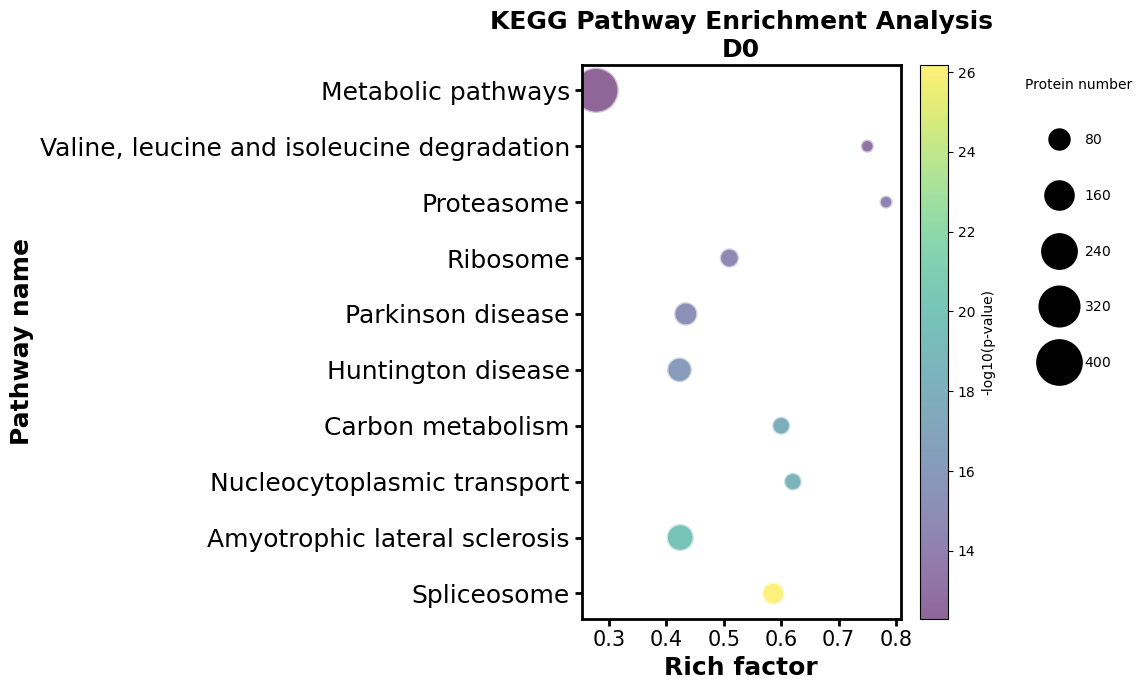

In [ ]:
#@title **Kyoto Encyclopedia of Genes and Genomes (KEGG) plots for a given experimental group**

import pandas as pd
from gprofiler import GProfiler
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from IPython.display import display

plt.rcParams['font.family'] = 'DejaVu Sans'
data = pd.read_csv('TABLES/Quantitative_parameters.csv', sep=',')
unique_genes = data['Genes'].unique().tolist()
gp = GProfiler(return_dataframe=True)

def perform_kegg_analysis(genes, organism):
    results = gp.profile(organism=organism, query=genes, sources=['KEGG'])
    significant_results = results[results['p_value'] < 0.05]
    return significant_results

def plot_kegg_results(results, filename, group_name):
    kegg_results = results[results['source'] == 'KEGG']
    kegg_results['rich_factor'] = kegg_results['intersection_size'] / kegg_results['term_size']
    kegg_results = kegg_results.nsmallest(10, 'p_value')

    if not kegg_results.empty:
        plt.figure(figsize=(12, 7))
        scale_factor = 2.5
        bubble = plt.scatter(
            kegg_results['rich_factor'],
            kegg_results['name'],
            s=np.clip(kegg_results['intersection_size'] * scale_factor, a_min=10, a_max=None),
            c=-np.log10(kegg_results['p_value']),
            cmap='viridis',
            alpha=0.6,
            edgecolors="w",
            linewidth=2
        )
        cbar = plt.colorbar(bubble, label='-log10(p-value)')
        cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}'))

        plt.xlabel('Rich factor', fontweight='bold', fontsize=18)
        plt.ylabel('Pathway name', fontweight='bold', fontsize=18)
        plt.title(f'KEGG Pathway Enrichment Analysis\n{group_name}', fontweight='bold', fontsize=18)
        plt.tick_params(axis='x', which='both', bottom=True, length=5, width=2, color='black')
        plt.tick_params(axis='y', which='both', left=True, length=5, width=2, color='black')
        plt.yticks(fontsize=18)
        plt.xticks(fontsize=15)
        plt.grid(False)
        ax1 = plt.gca()
        for spine in ax1.spines.values():
            spine.set_edgecolor('black')
            spine.set_linewidth(2)

        handles, labels = bubble.legend_elements(prop="sizes", alpha=1, num=6, func=lambda s: s / scale_factor)
        legend2 = plt.legend(handles, labels, loc="upper left", bbox_to_anchor=(1.35, 1), title="Protein number", markerscale=1, labelspacing=3, frameon=False)
        plt.tight_layout()
        plt.savefig(f'PLOTS/{filename}_{group_name}.tiff', dpi=300, format='tiff')
        plt.show()
    else:
        print("No significant KEGG results to plot.")

group_dropdown = widgets.Dropdown(
    options=data['Experimental groups'].unique().tolist(),
    description='Experimental Groups:',
    style={'description_width': 'initial'}
)

organism_dropdown = widgets.Dropdown(
    options=['hsapiens', 'mmusculus', 'scerevisiae'],
    description='Organism:',
    style={'description_width': 'initial'}
)

plot_button = widgets.Button(
    description="Display Plot",
    style={'font_weight': 'bold', 'button_color': '#4CAF50', 'font_size': '16px'},
    layout=widgets.Layout(width='auto', height='40px')
)

def on_button_click(b):
    selected_group = group_dropdown.value
    group_genes = data[data['Experimental groups'] == selected_group]['Genes'].unique().tolist()


    group_genes = [gene for gene in group_genes if pd.notna(gene)]

    selected_organism = organism_dropdown.value
    significant_results = perform_kegg_analysis(group_genes, selected_organism)
    plot_kegg_results(significant_results, 'KEGG_enrichment', selected_group)

plot_button.on_click(on_button_click)
display(organism_dropdown, group_dropdown, plot_button)


Dropdown(description='Select File:', options=('D0 vs D2_Total_proteins.csv',), style=DescriptionStyle(descript…

Dropdown(description='Organism:', options=('hsapiens', 'mmusculus', 'scerevisiae'), style=DescriptionStyle(des…

Button(description='Display Plot', layout=Layout(height='40px', width='auto'), style=ButtonStyle(button_color=…

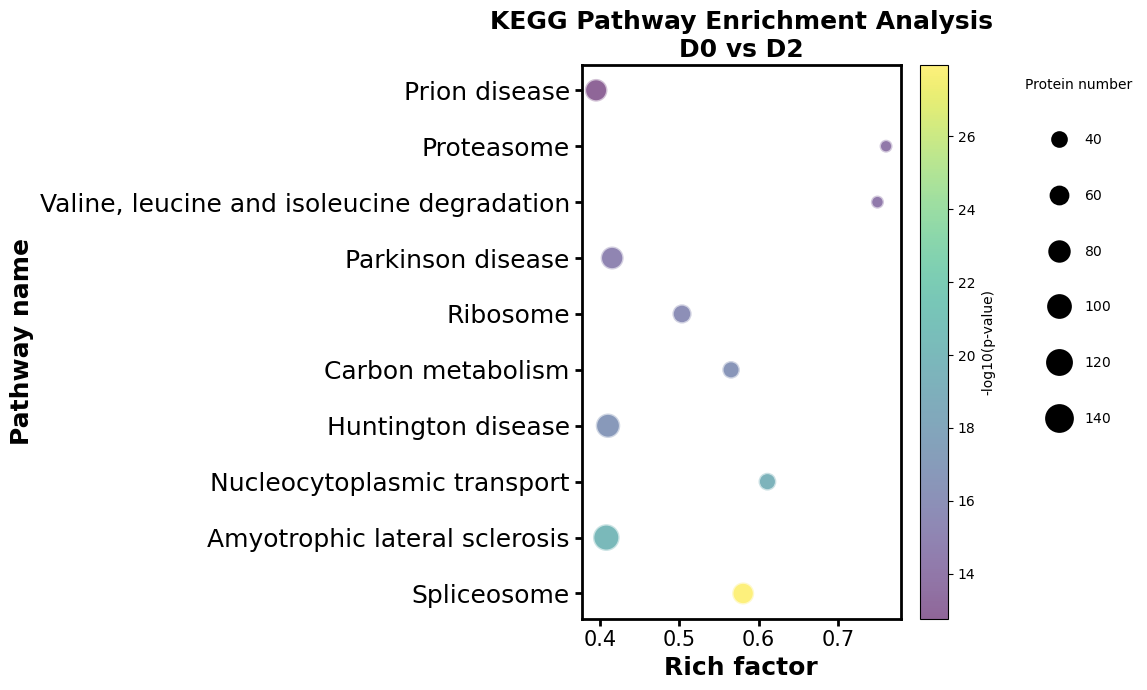

In [ ]:
#@title **Kyoto Encyclopedia of Genes and Genomes (KEGG) plots for all proteins from a given experimental group comparison**
import pandas as pd
from gprofiler import GProfiler
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from IPython.display import display
import os

plt.rcParams['font.family'] = 'DejaVu Sans'
gp = GProfiler(return_dataframe=True)

def perform_kegg_analysis(genes, organism):
    results = gp.profile(organism=organism, query=genes, sources=['KEGG'])
    significant_results = results[results['p_value'] < 0.05]
    return significant_results

def plot_kegg_results(results, filename, comparison_name):
    kegg_results = results[results['source'] == 'KEGG']
    kegg_results['rich_factor'] = kegg_results['intersection_size'] / kegg_results['term_size']
    kegg_results = kegg_results.nsmallest(10, 'p_value')

    if not kegg_results.empty:
        plt.figure(figsize=(12, 7))
        scale_factor = 2.5
        bubble = plt.scatter(
            kegg_results['rich_factor'],
            kegg_results['name'],
            s=np.clip(kegg_results['intersection_size'] * scale_factor, a_min=10, a_max=None),
            c=-np.log10(kegg_results['p_value']),
            cmap='viridis',
            alpha=0.6,
            edgecolors="w",
            linewidth=2
        )

        cbar = plt.colorbar(bubble, label='-log10(p-value)')
        cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}'))

        plt.xlabel('Rich factor', fontweight='bold', fontsize=18)
        plt.ylabel('Pathway name', fontweight='bold', fontsize=18)
        plt.title(f'KEGG Pathway Enrichment Analysis\n{comparison_name}', fontweight='bold', fontsize=18)
        plt.tick_params(axis='x', which='both', bottom=True, length=5, width=2, color='black')
        plt.tick_params(axis='y', which='both', left=True, length=5, width=2, color='black')
        plt.xticks(fontsize=15)
        plt.yticks(fontsize=18)
        plt.grid(False)
        ax1 = plt.gca()
        for spine in ax1.spines.values():
            spine.set_edgecolor('black')
            spine.set_linewidth(2)

        handles, labels = bubble.legend_elements(prop="sizes", alpha=1, num=6, func=lambda s: s / scale_factor)
        legend2 = plt.legend(handles, labels, loc="upper left", bbox_to_anchor=(1.35, 1), title="Protein number", markerscale=1, labelspacing=3, frameon=False)
        plt.tight_layout()
        plt.savefig(f'PLOTS/{filename}_{comparison_name}.tiff', dpi=300, format='tiff')
        plt.show()
    else:
        print("No significant KEGG results to plot.")

organism_dropdown = widgets.Dropdown(
    options=['hsapiens', 'mmusculus', 'scerevisiae'],
    description='Organism:',
    style={'description_width': 'initial'}
)

file_options = [f for f in os.listdir('TABLES/VOLCANO_PLOT_VALUES') if f.endswith('_Total_proteins.csv')]
file_dropdown = widgets.Dropdown(
    options=file_options,
    description='Select File:',
    style={'description_width': 'initial'}
)

plot_button = widgets.Button(
    description="Display Plot",
    style={'font_weight': 'bold', 'button_color': '#4CAF50', 'font_size': '16px'},
    layout=widgets.Layout(width='auto', height='40px')
)

def on_button_click(b):
    selected_file = file_dropdown.value
    data = pd.read_csv(f'TABLES/VOLCANO_PLOT_VALUES/{selected_file}', sep=',')

    comparison_name = data['Comparison'].iloc[0]
    group_genes = data['Genes'].unique().tolist()
    group_genes = [gene for gene in group_genes if pd.notna(gene)]

    selected_organism = organism_dropdown.value
    significant_results = perform_kegg_analysis(group_genes, selected_organism)
    plot_kegg_results(significant_results, 'KEGG_enrichment', comparison_name)

plot_button.on_click(on_button_click)
display(file_dropdown, organism_dropdown, plot_button)

Dropdown(description='Select File:', options=('D0 vs D2_Upregulated.csv',), style=DescriptionStyle(description…

Dropdown(description='Organism:', options=('hsapiens', 'mmusculus', 'scerevisiae'), style=DescriptionStyle(des…

Button(description='Display Plot', layout=Layout(height='40px', width='auto'), style=ButtonStyle(button_color=…

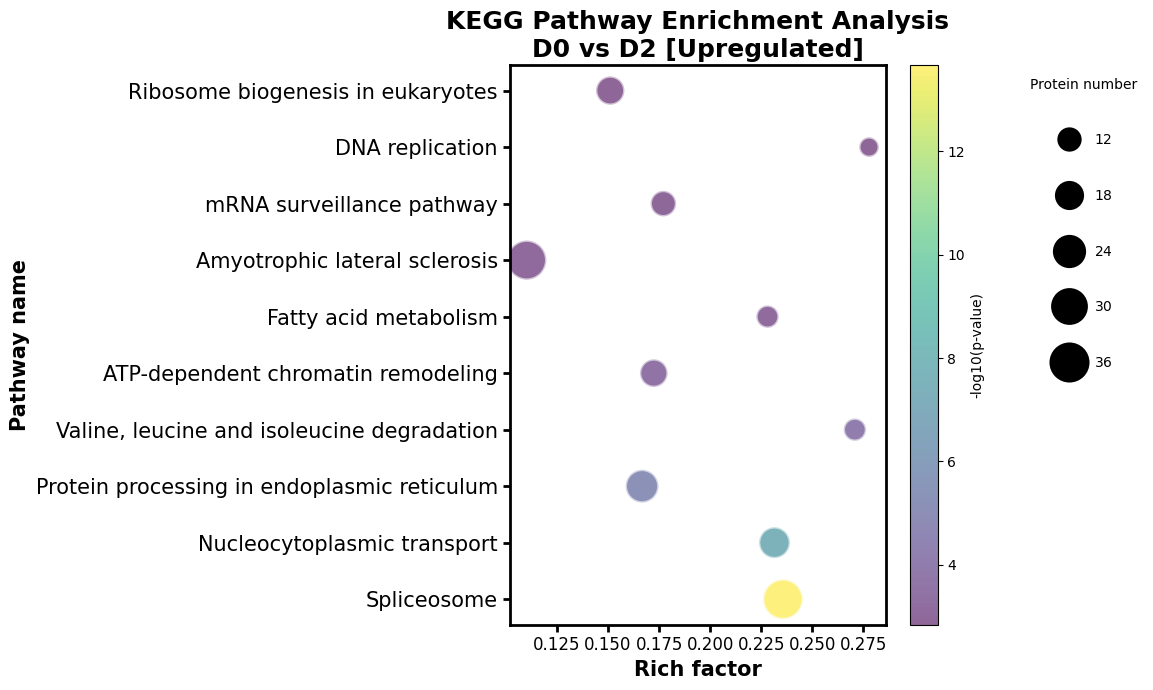

In [ ]:
#@title **Kyoto Encyclopedia of Genes and Genomes (KEGG) plots for all proteins from a given experimental group comparison - Upregulated Proteins**
import pandas as pd
from gprofiler import GProfiler
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from IPython.display import display
import os

plt.rcParams['font.family'] = 'DejaVu Sans'
gp = GProfiler(return_dataframe=True)

def perform_kegg_analysis(genes, organism):
    results = gp.profile(organism=organism, query=genes, sources=['KEGG'])
    results['p_value'] = pd.to_numeric(results['p_value'], errors='coerce')
    significant_results = results[results['p_value'] < 0.05]
    return significant_results

def plot_kegg_results(results, filename, comparison_name):
    kegg_results = results[results['source'] == 'KEGG']
    kegg_results['rich_factor'] = kegg_results['intersection_size'] / kegg_results['term_size']
    kegg_results = kegg_results.nsmallest(10, 'p_value')

    if not kegg_results.empty:
        plt.figure(figsize=(12, 7))
        scale_factor = 20
        bubble = plt.scatter(
            kegg_results['rich_factor'],
            kegg_results['name'],
            s=np.clip(kegg_results['intersection_size'] * scale_factor, a_min=10, a_max=None),
            c=-np.log10(kegg_results['p_value']),
            cmap='viridis',
            alpha=0.6,
            edgecolors="w",
            linewidth=2
        )

        cbar = plt.colorbar(bubble, label='-log10(p-value)')
        cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}'))

        plt.xlabel('Rich factor', fontweight='bold', fontsize=15)
        plt.ylabel('Pathway name', fontweight='bold', fontsize=15)
        plt.title(f'KEGG Pathway Enrichment Analysis\n{comparison_name} [Upregulated]', fontweight='bold', fontsize=18)
        plt.tick_params(axis='x', which='both', bottom=True, length=5, width=2, color='black')
        plt.tick_params(axis='y', which='both', left=True, length=5, width=2, color='black')
        plt.xticks(fontsize=12)
        plt.yticks(fontsize=15)
        plt.grid(False)
        ax1 = plt.gca()
        for spine in ax1.spines.values():
            spine.set_edgecolor('black')
            spine.set_linewidth(2)

        handles, labels = bubble.legend_elements(prop="sizes", alpha=1, num=6, func=lambda s: s / scale_factor)
        legend2 = plt.legend(handles, labels, loc="upper left", bbox_to_anchor=(1.35, 1), title="Protein number", markerscale=1, labelspacing=3, frameon=False)
        plt.tight_layout()
        plt.savefig(f'PLOTS/{filename}_{comparison_name}_Upregulated.tiff', dpi=300, format='tiff')
        plt.show()
    else:
        print("No significant KEGG results to plot.")

organism_dropdown = widgets.Dropdown(
    options=['hsapiens', 'mmusculus', 'scerevisiae'],
    description='Organism:',
    style={'description_width': 'initial'}
)

file_options = [f for f in os.listdir('TABLES/VOLCANO_PLOT_VALUES') if f.endswith('_Upregulated.csv')]
file_dropdown = widgets.Dropdown(
    options=file_options,
    description='Select File:',
    style={'description_width': 'initial'}
)

plot_button = widgets.Button(
    description="Display Plot",
    style={'font_weight': 'bold', 'button_color': '#4CAF50', 'font_size': '16px'},
    layout=widgets.Layout(width='auto', height='40px')
)

def on_button_click(b):
    selected_file = file_dropdown.value
    data = pd.read_csv(f'TABLES/VOLCANO_PLOT_VALUES/{selected_file}', sep=',')

    comparison_name = data['Comparison'].iloc[0]
    group_genes = data['Genes'].unique().tolist()
    group_genes = [gene for gene in group_genes if pd.notna(gene)]

    selected_organism = organism_dropdown.value
    significant_results = perform_kegg_analysis(group_genes, selected_organism)
    plot_kegg_results(significant_results, 'KEGG_enrichment', comparison_name)

plot_button.on_click(on_button_click)
display(file_dropdown, organism_dropdown, plot_button)

Dropdown(description='Select File:', options=('D0 vs D2_Downregulated.csv',), style=DescriptionStyle(descripti…

Dropdown(description='Organism:', options=('hsapiens', 'mmusculus', 'scerevisiae'), style=DescriptionStyle(des…

Button(description='Display Plot', layout=Layout(height='40px', width='auto'), style=ButtonStyle(button_color=…

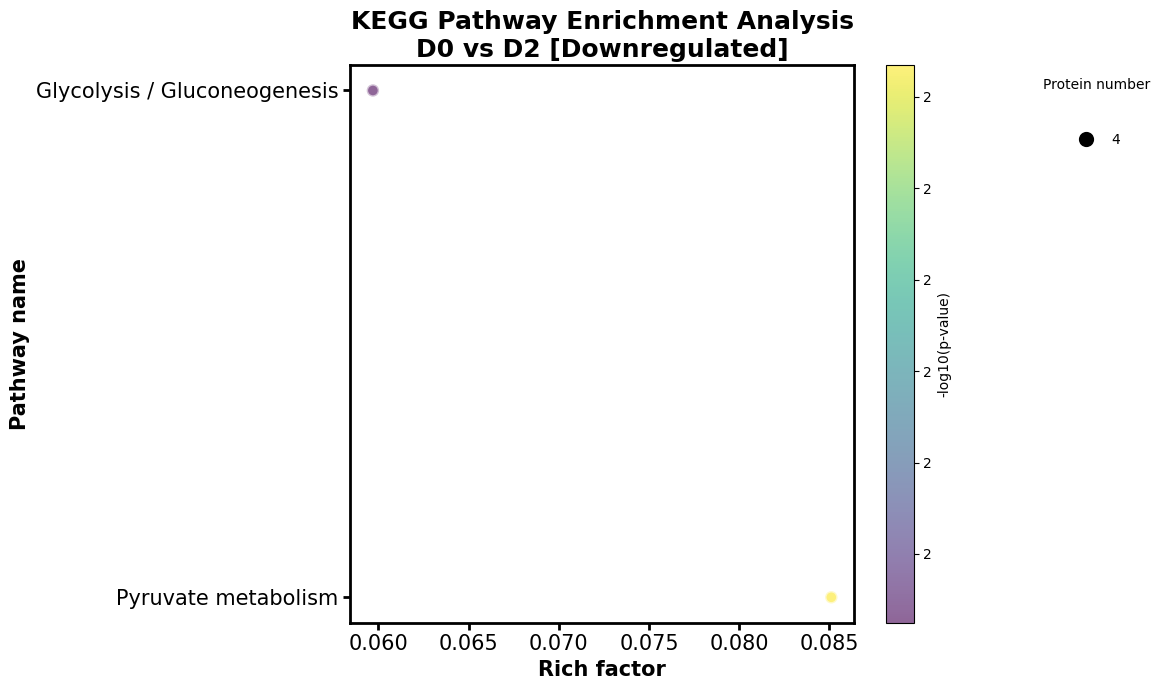

In [ ]:
#@title **Kyoto Encyclopedia of Genes and Genomes (KEGG) plots for all proteins from a given experimental group comparison - Downregulated Proteins**
import pandas as pd
from gprofiler import GProfiler
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from IPython.display import display
import os

plt.rcParams['font.family'] = 'DejaVu Sans'
gp = GProfiler(return_dataframe=True)

def perform_kegg_analysis(genes, organism):
    results = gp.profile(organism=organism, query=genes, sources=['KEGG'])
    results['p_value'] = pd.to_numeric(results['p_value'], errors='coerce')
    significant_results = results[results['p_value'] < 0.05]
    return significant_results

def plot_kegg_results(results, filename, comparison_name):
    kegg_results = results[results['source'] == 'KEGG']
    kegg_results['rich_factor'] = kegg_results['intersection_size'] / kegg_results['term_size']
    kegg_results = kegg_results.nsmallest(10, 'p_value')

    if not kegg_results.empty:
        plt.figure(figsize=(12, 7))
        scale_factor = 20
        bubble = plt.scatter(
            kegg_results['rich_factor'],
            kegg_results['name'],
            s=np.clip(kegg_results['intersection_size'] * scale_factor, a_min=10, a_max=None),
            c=-np.log10(kegg_results['p_value']),
            cmap='viridis',
            alpha=0.6,
            edgecolors="w",
            linewidth=2
        )

        cbar = plt.colorbar(bubble, label='-log10(p-value)')
        cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}'))

        plt.xlabel('Rich factor', fontweight='bold', fontsize=15)
        plt.ylabel('Pathway name', fontweight='bold', fontsize=15)
        plt.title(f'KEGG Pathway Enrichment Analysis\n{comparison_name} [Downregulated]', fontweight='bold', fontsize=18)
        plt.tick_params(axis='x', which='both', bottom=True, length=5, width=2, color='black')
        plt.tick_params(axis='y', which='both', left=True, length=5, width=2, color='black')
        plt.xticks(fontsize=15)
        plt.yticks(fontsize=15)
        plt.grid(False)
        ax1 = plt.gca()
        for spine in ax1.spines.values():
            spine.set_edgecolor('black')
            spine.set_linewidth(2)

        handles, labels = bubble.legend_elements(prop="sizes", alpha=1, num=6, func=lambda s: s / scale_factor)
        legend2 = plt.legend(handles, labels, loc="upper left", bbox_to_anchor=(1.35, 1), title="Protein number", markerscale=1, labelspacing=3, frameon=False)
        plt.tight_layout()
        plt.savefig(f'PLOTS/{filename}_{comparison_name}_Downregulated.tiff', dpi=300, format='tiff')
        plt.show()
    else:
        print("No significant KEGG results to plot.")

organism_dropdown = widgets.Dropdown(
    options=['hsapiens', 'mmusculus', 'scerevisiae'],
    description='Organism:',
    style={'description_width': 'initial'}
)

file_options = [f for f in os.listdir('TABLES/VOLCANO_PLOT_VALUES') if f.endswith('_Downregulated.csv')]
file_dropdown = widgets.Dropdown(
    options=file_options,
    description='Select File:',
    style={'description_width': 'initial'}
)

plot_button = widgets.Button(
    description="Display Plot",
    style={'font_weight': 'bold', 'button_color': '#4CAF50', 'font_size': '16px'},
    layout=widgets.Layout(width='auto', height='40px')
)

def on_button_click(b):
    selected_file = file_dropdown.value
    data = pd.read_csv(f'TABLES/VOLCANO_PLOT_VALUES/{selected_file}', sep=',')

    comparison_name = data['Comparison'].iloc[0]
    group_genes = data['Genes'].unique().tolist()
    group_genes = [gene for gene in group_genes if pd.notna(gene)]

    selected_organism = organism_dropdown.value
    significant_results = perform_kegg_analysis(group_genes, selected_organism)
    plot_kegg_results(significant_results, 'KEGG_enrichment', comparison_name)

plot_button.on_click(on_button_click)
display(file_dropdown, organism_dropdown, plot_button)

Dropdown(description='Organism:', options=('hsapiens', 'mmusculus', 'scerevisiae'), style=DescriptionStyle(des…

Dropdown(description='Experimental Groups:', options=('D0', 'D2', 'D4', 'D6', 'D8', 'D10', 'D11', 'D12', 'D14'…

Button(description='Display Plot', layout=Layout(height='40px', width='auto'), style=ButtonStyle(button_color=…

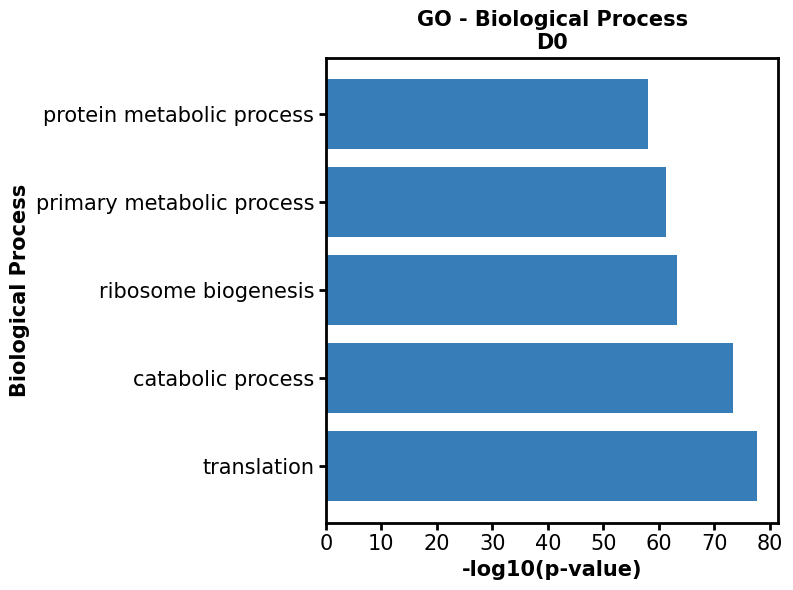

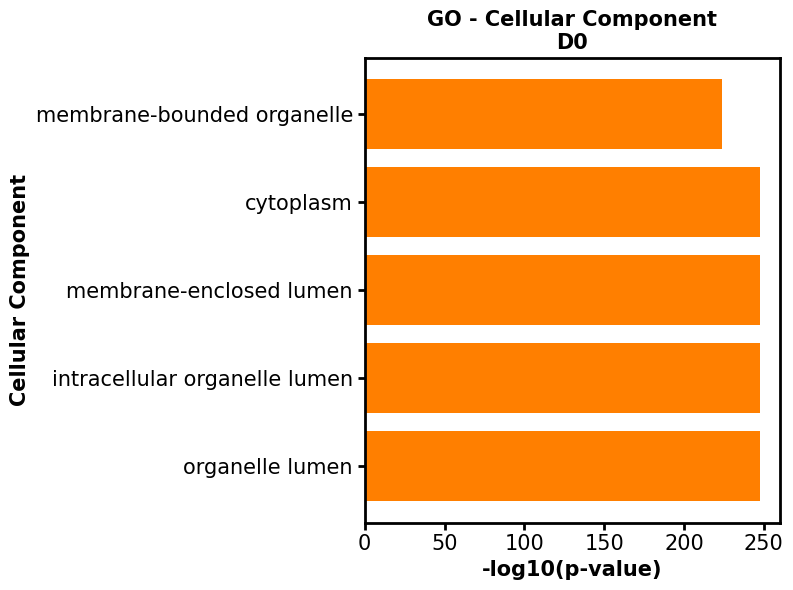

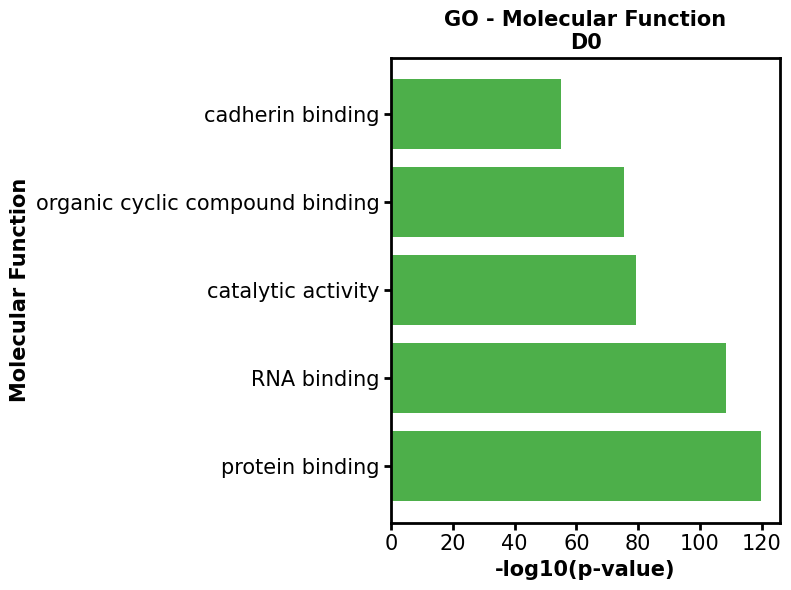

In [ ]:
#@title **Gene ontology (GO) plots for a given experimental group**
import pandas as pd
from gprofiler import GProfiler
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from IPython.display import display

plt.rcParams['font.family'] = 'DejaVu Sans'

data = pd.read_csv('TABLES/Quantitative_parameters.csv')
unique_genes = data['Genes'].unique().tolist()

gp = GProfiler(return_dataframe=True)

def perform_go_analysis(genes, organism):
    results = gp.profile(organism=organism, query=genes, sources=['GO:BP', 'GO:CC', 'GO:MF'])
    significant_results = results[results['p_value'] < 0.05]
    return significant_results

def customize_plot():
    plt.tick_params(axis='x', which='both', bottom=True, length=5, width=2, color='black')
    plt.tick_params(axis='y', which='both', left=True, length=5, width=2, color='black')
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.grid(False)
    ax1 = plt.gca()
    for spine in ax1.spines.values():
        spine.set_linewidth(2)
        spine.set_color("k")

def plot_go_results(results, source, color, ylabel, title, filename):
    if not results.empty:
        plt.figure(figsize=(8, 6))
        plt.barh(results['name'], -np.log10(results['p_value']), color=color)
        plt.xlabel('-log10(p-value)', fontweight='bold', fontsize=15)
        plt.ylabel(ylabel, fontweight='bold', fontsize=15)
        plt.title(title, fontweight='bold', fontsize=15)
        customize_plot()
        plt.tight_layout()
        plt.savefig(f'PLOTS/{filename}.tiff', dpi=300, format='tiff')
        plt.show()
    else:
        print(f"No significant {ylabel} results to plot.")

group_dropdown = widgets.Dropdown(
    options=data['Experimental groups'].unique().tolist(),
    description='Experimental Groups:',
    style={'description_width': 'initial'}
)

organism_dropdown = widgets.Dropdown(
    options=['hsapiens', 'mmusculus', 'scerevisiae'],
    description='Organism:',
    style={'description_width': 'initial'}
)

plot_button = widgets.Button(
    description="Display Plot",
    style={'font_weight': 'bold', 'button_color': '#4CAF50', 'font_size': '16px'},
    layout=widgets.Layout(width='auto', height='40px')
)

def on_button_click(b):
    selected_group = group_dropdown.value
    group_genes = data[data['Experimental groups'] == selected_group]['Genes'].unique().tolist()

    group_genes = [gene for gene in group_genes if pd.notna(gene)]

    selected_organism = organism_dropdown.value
    significant_results = perform_go_analysis(group_genes, selected_organism)

    bp_results = significant_results[significant_results['source'] == 'GO:BP'].nsmallest(5, 'p_value')
    cc_results = significant_results[significant_results['source'] == 'GO:CC'].nsmallest(5, 'p_value')
    mf_results = significant_results[significant_results['source'] == 'GO:MF'].nsmallest(5, 'p_value')

    plot_go_results(bp_results, 'GO:BP', '#377eb8', 'Biological Process', f'GO - Biological Process\n{selected_group}', f'GO_BP_enrichment_{selected_group}')
    plot_go_results(cc_results, 'GO:CC', '#ff7f00', 'Cellular Component', f'GO - Cellular Component\n{selected_group}', f'GO_CC_enrichment_{selected_group}')
    plot_go_results(mf_results, 'GO:MF', '#4daf4a', 'Molecular Function', f'GO - Molecular Function\n{selected_group}', f'GO_MF_enrichment_{selected_group}')

plot_button.on_click(on_button_click)
display(organism_dropdown, group_dropdown, plot_button)



Dropdown(description='Select File:', options=('D0 vs D2_Total_proteins.csv',), style=DescriptionStyle(descript…

Dropdown(description='Organism:', options=('hsapiens', 'mmusculus', 'scerevisiae'), style=DescriptionStyle(des…

Button(description='Display Plot', layout=Layout(height='40px', width='auto'), style=ButtonStyle(button_color=…

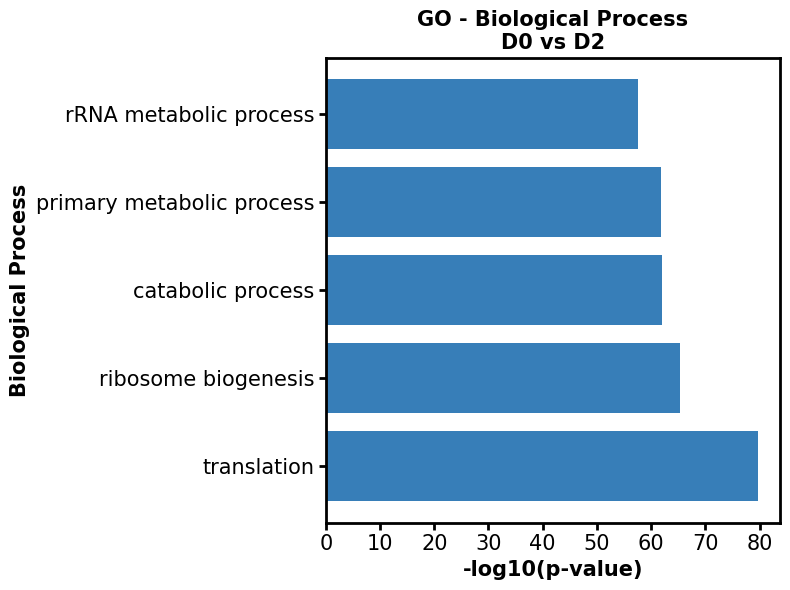

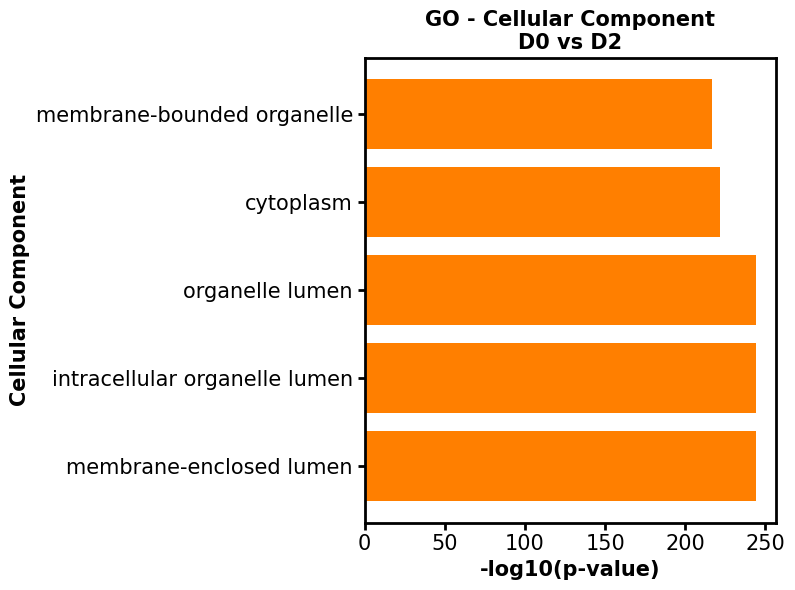

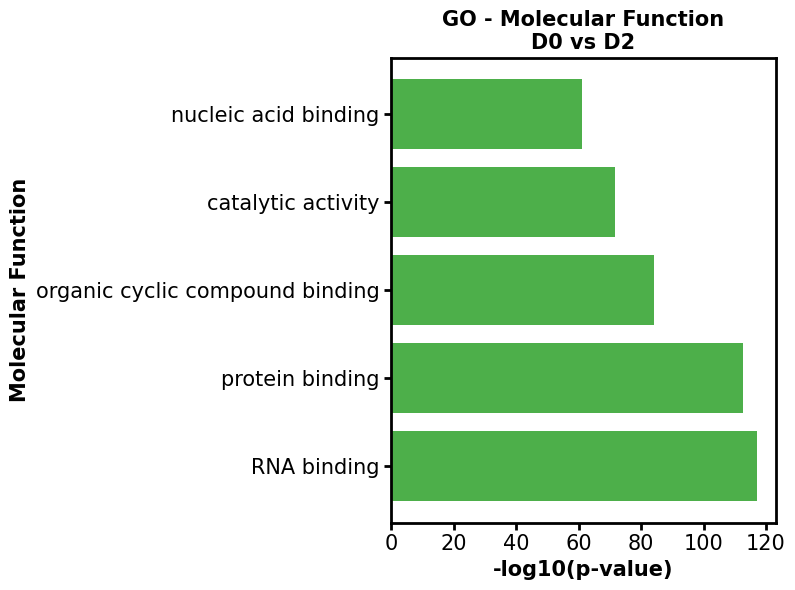

In [ ]:
#@title **Gene ontology (GO) plots for all proteins from a given experimental group comparison**
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from gprofiler import GProfiler
import os


plt.rcParams['font.family'] = 'DejaVu Sans'
file_options = [f for f in os.listdir('TABLES/VOLCANO_PLOT_VALUES') if f.endswith('_Total_proteins.csv')]
file_dropdown = widgets.Dropdown(
    options=file_options,
    description='Select File:',
    style={'description_width': 'initial'}
)

gp = GProfiler(return_dataframe=True)

def perform_go_analysis(genes, organism):
    results = gp.profile(organism=organism, query=genes, sources=['GO:BP', 'GO:CC', 'GO:MF'])
    significant_results = results[results['p_value'] < 0.05]
    return significant_results

def customize_plot():
    plt.tick_params(axis='x', which='both', bottom=True, length=5, width=2, color='black')
    plt.tick_params(axis='y', which='both', left=True, length=5, width=2, color='black')
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.grid(False)
    ax1 = plt.gca()
    for spine in ax1.spines.values():
        spine.set_linewidth(2)
        spine.set_color("k")

def plot_go_results(results, source, color, ylabel, title, comparison_name):
    if not results.empty:
        plt.figure(figsize=(8, 6))
        plt.barh(results['name'], -np.log10(results['p_value']), color=color)
        plt.xlabel('-log10(p-value)', fontweight='bold', fontsize=15)
        plt.ylabel(ylabel, fontweight='bold', fontsize=15)
        plt.title(f'{title}\n{comparison_name}', fontweight='bold', fontsize=15)
        customize_plot()
        plt.tight_layout()
        plt.savefig(f'PLOTS/{ylabel}_{comparison_name}.tiff', dpi=300, format='tiff')
        plt.show()
    else:
        print(f"No significant {ylabel} results to plot.")

organism_dropdown = widgets.Dropdown(
    options=['hsapiens', 'mmusculus', 'scerevisiae'],
    description='Organism:',
    style={'description_width': 'initial'}
)

plot_button = widgets.Button(
    description="Display Plot",
    style={'font_weight': 'bold', 'button_color': '#4CAF50', 'font_size': '16px'},
    layout=widgets.Layout(width='auto', height='40px')
)


def on_button_click(b):
    selected_file = file_dropdown.value
    data = pd.read_csv(f'TABLES/VOLCANO_PLOT_VALUES/{selected_file}', sep=',')

    comparison_name = data['Comparison'].iloc[0]

    group_genes = data['Genes'].unique().tolist()
    group_genes = [gene for gene in group_genes if pd.notna(gene)]

    if not group_genes:
        print("No genes found in the selected file.")
        return

    selected_organism = organism_dropdown.value
    significant_results = perform_go_analysis(group_genes, selected_organism)

    if significant_results.empty:
        print("No significant results found.")
        return

    bp_results = significant_results[significant_results['source'] == 'GO:BP'].nsmallest(5, 'p_value')
    cc_results = significant_results[significant_results['source'] == 'GO:CC'].nsmallest(5, 'p_value')
    mf_results = significant_results[significant_results['source'] == 'GO:MF'].nsmallest(5, 'p_value')

    plot_go_results(bp_results, 'GO:BP', '#377eb8', 'Biological Process', 'GO - Biological Process', comparison_name)
    plot_go_results(cc_results, 'GO:CC', '#ff7f00', 'Cellular Component', 'GO - Cellular Component', comparison_name)
    plot_go_results(mf_results, 'GO:MF', '#4daf4a', 'Molecular Function', 'GO - Molecular Function', comparison_name)

plot_button.on_click(on_button_click)
display(file_dropdown, organism_dropdown, plot_button)


Dropdown(description='Select File:', options=('D0 vs D2_Upregulated.csv',), style=DescriptionStyle(description…

Dropdown(description='Organism:', options=('hsapiens', 'mmusculus', 'scerevisiae'), style=DescriptionStyle(des…

Button(description='Display Plot', layout=Layout(height='40px', width='auto'), style=ButtonStyle(button_color=…

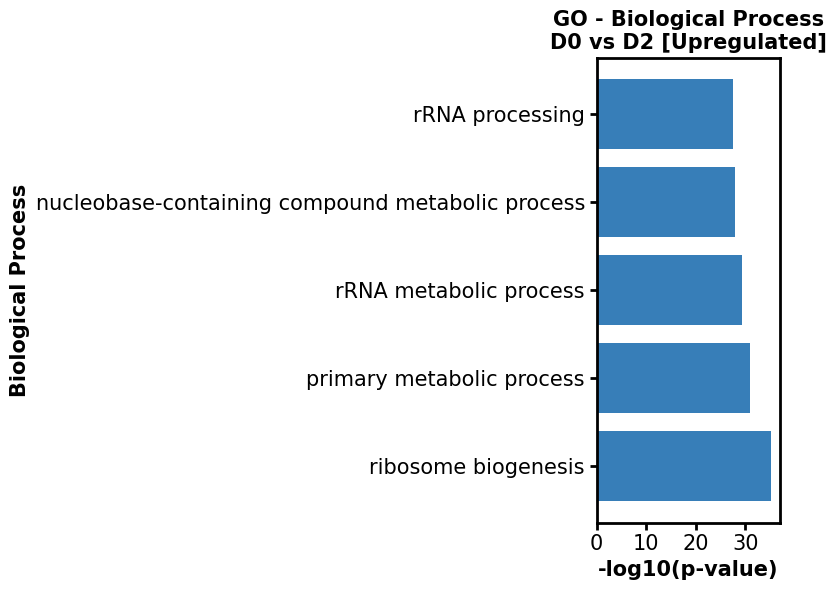

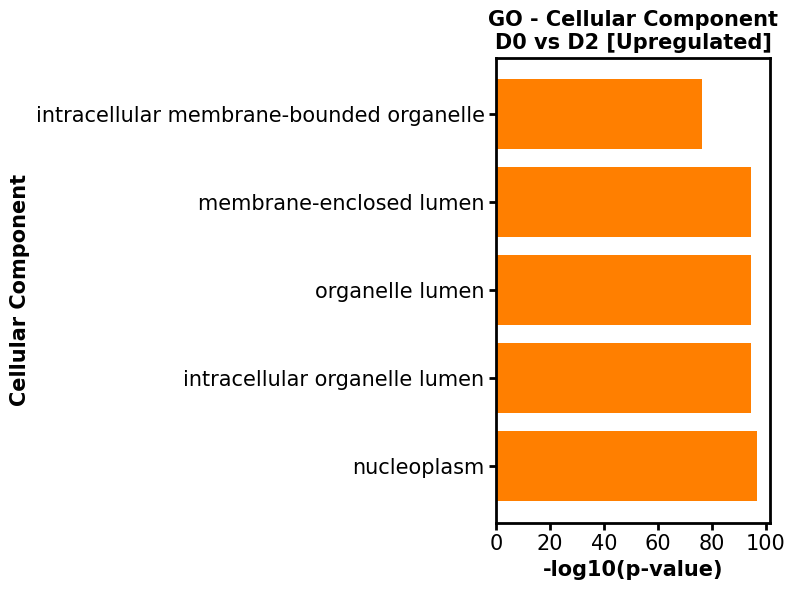

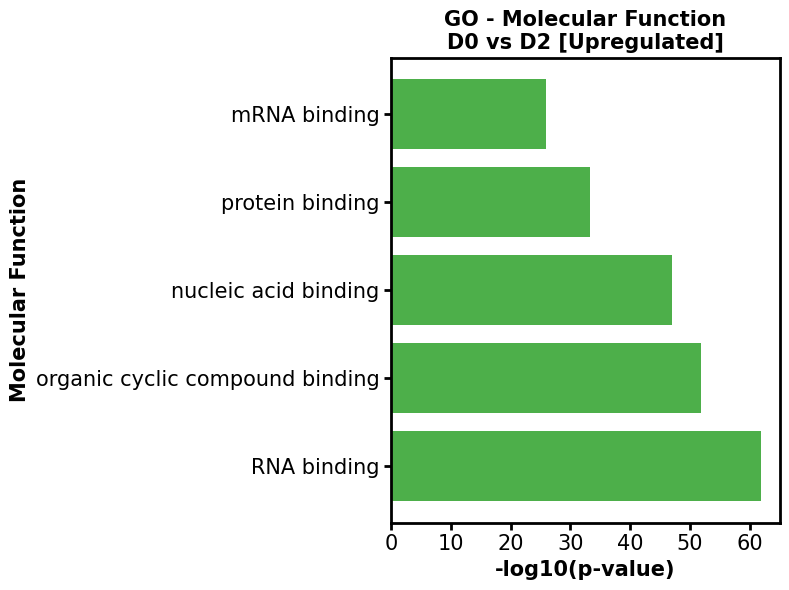

In [ ]:
#@title **Gene ontology (GO) plots for all proteins from a given experimental group comparison - Upregulated Proteins**
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from gprofiler import GProfiler
import os


plt.rcParams['font.family'] = 'DejaVu Sans'
file_options = [f for f in os.listdir('TABLES/VOLCANO_PLOT_VALUES') if f.endswith('_Upregulated.csv')]
file_dropdown = widgets.Dropdown(
    options=file_options,
    description='Select File:',
    style={'description_width': 'initial'}
)

gp = GProfiler(return_dataframe=True)

def perform_go_analysis(genes, organism):
    results = gp.profile(organism=organism, query=genes, sources=['GO:BP', 'GO:CC', 'GO:MF'])
    significant_results = results[results['p_value'] < 0.05]
    return significant_results

def customize_plot():
    plt.tick_params(axis='x', which='both', bottom=True, length=5, width=2, color='black')
    plt.tick_params(axis='y', which='both', left=True, length=5, width=2, color='black')
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.grid(False)
    ax1 = plt.gca()
    for spine in ax1.spines.values():
        spine.set_linewidth(2)
        spine.set_color("k")

def plot_go_results(results, source, color, ylabel, title, comparison_name):
    if not results.empty:
        plt.figure(figsize=(8, 6))
        plt.barh(results['name'], -np.log10(results['p_value']), color=color)
        plt.xlabel('-log10(p-value)', fontweight='bold', fontsize=15)
        plt.ylabel(ylabel, fontweight='bold', fontsize=15)
        plt.title(f'{title}\n{comparison_name} [Upregulated]', fontweight='bold', fontsize=15)
        customize_plot()
        plt.tight_layout()
        plt.savefig(f'PLOTS/{ylabel}_{comparison_name}_Upregulated.tiff', dpi=300, format='tiff')
        plt.show()
    else:
        print(f"No significant {ylabel} results to plot.")

organism_dropdown = widgets.Dropdown(
    options=['hsapiens', 'mmusculus', 'scerevisiae'],
    description='Organism:',
    style={'description_width': 'initial'}
)

plot_button = widgets.Button(
    description="Display Plot",
    style={'font_weight': 'bold', 'button_color': '#4CAF50', 'font_size': '16px'},
    layout=widgets.Layout(width='auto', height='40px')
)


def on_button_click(b):
    selected_file = file_dropdown.value
    data = pd.read_csv(f'TABLES/VOLCANO_PLOT_VALUES/{selected_file}', sep=',')

    comparison_name = data['Comparison'].iloc[0]

    group_genes = data['Genes'].unique().tolist()
    group_genes = [gene for gene in group_genes if pd.notna(gene)]

    if not group_genes:
        print("No genes found in the selected file.")
        return

    selected_organism = organism_dropdown.value
    significant_results = perform_go_analysis(group_genes, selected_organism)

    if significant_results.empty:
        print("No significant results found.")
        return

    bp_results = significant_results[significant_results['source'] == 'GO:BP'].nsmallest(5, 'p_value')
    cc_results = significant_results[significant_results['source'] == 'GO:CC'].nsmallest(5, 'p_value')
    mf_results = significant_results[significant_results['source'] == 'GO:MF'].nsmallest(5, 'p_value')

    plot_go_results(bp_results, 'GO:BP', '#377eb8', 'Biological Process', 'GO - Biological Process', comparison_name)
    plot_go_results(cc_results, 'GO:CC', '#ff7f00', 'Cellular Component', 'GO - Cellular Component', comparison_name)
    plot_go_results(mf_results, 'GO:MF', '#4daf4a', 'Molecular Function', 'GO - Molecular Function', comparison_name)

plot_button.on_click(on_button_click)
display(file_dropdown, organism_dropdown, plot_button)


Dropdown(description='Select File:', options=('D0 vs D2_Downregulated.csv',), style=DescriptionStyle(descripti…

Dropdown(description='Organism:', options=('hsapiens', 'mmusculus', 'scerevisiae'), style=DescriptionStyle(des…

Button(description='Display Plot', layout=Layout(height='40px', width='auto'), style=ButtonStyle(button_color=…

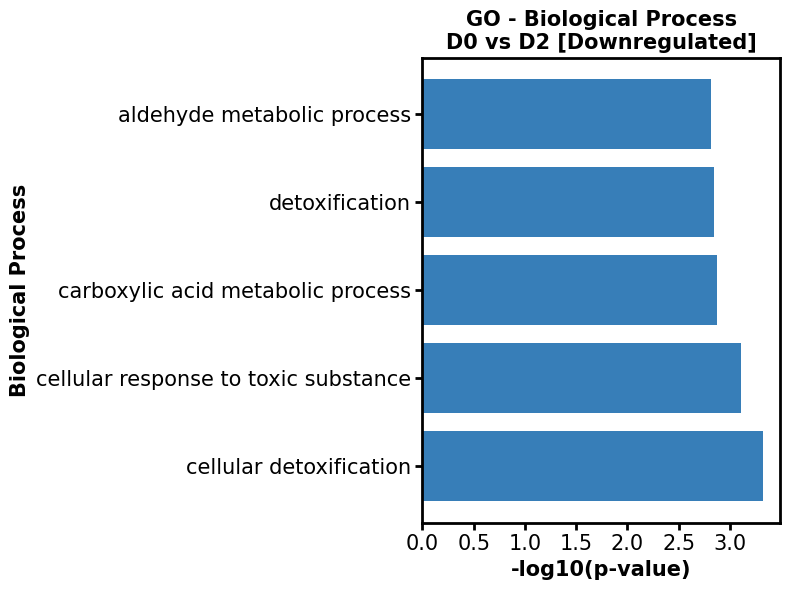

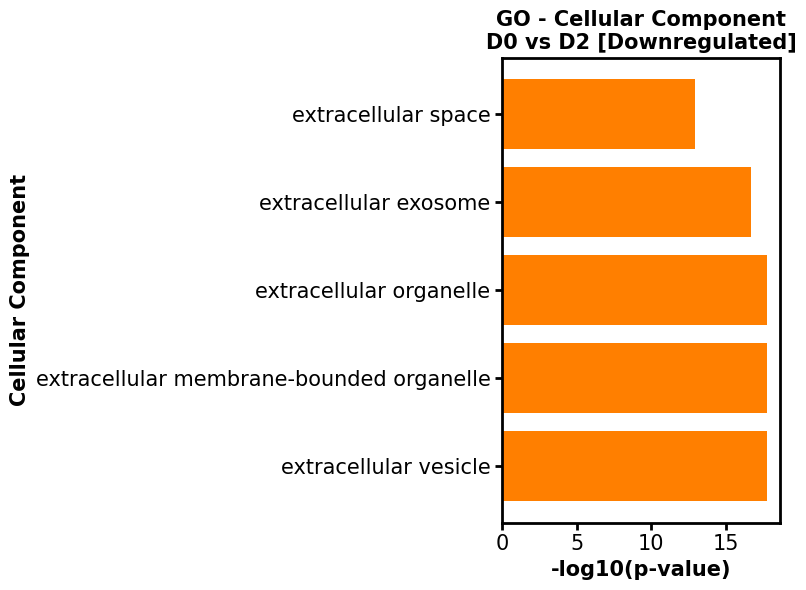

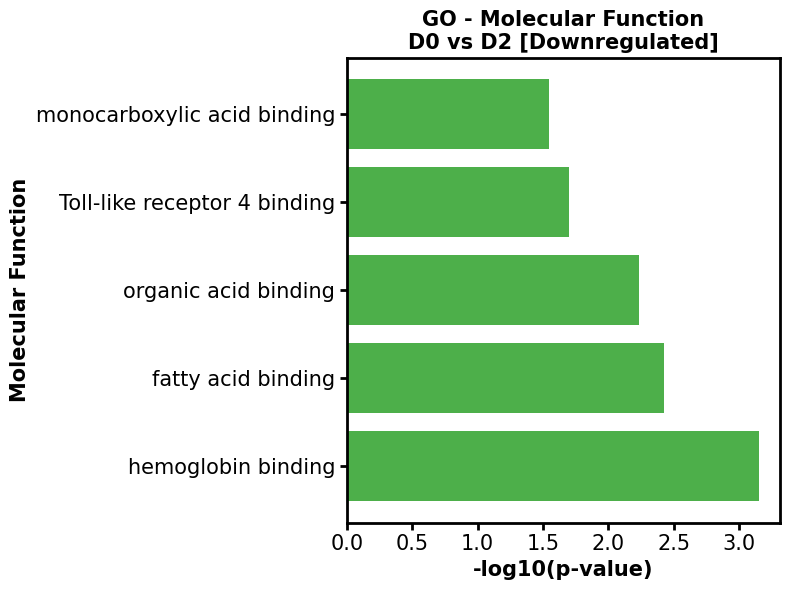

In [ ]:
#@title **Gene ontology (GO) plots for all proteins from a given experimental group comparison - Downregulated Proteins**
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from gprofiler import GProfiler
import os


plt.rcParams['font.family'] = 'DejaVu Sans'
file_options = [f for f in os.listdir('TABLES/VOLCANO_PLOT_VALUES') if f.endswith('_Downregulated.csv')]
file_dropdown = widgets.Dropdown(
    options=file_options,
    description='Select File:',
    style={'description_width': 'initial'}
)

gp = GProfiler(return_dataframe=True)

def perform_go_analysis(genes, organism):
    results = gp.profile(organism=organism, query=genes, sources=['GO:BP', 'GO:CC', 'GO:MF'])
    significant_results = results[results['p_value'] < 0.05]
    return significant_results

def customize_plot():
    plt.tick_params(axis='x', which='both', bottom=True, length=5, width=2, color='black')
    plt.tick_params(axis='y', which='both', left=True, length=5, width=2, color='black')
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.grid(False)
    ax1 = plt.gca()
    for spine in ax1.spines.values():
        spine.set_linewidth(2)
        spine.set_color("k")

def plot_go_results(results, source, color, ylabel, title, comparison_name):
    if not results.empty:
        plt.figure(figsize=(8, 6))
        plt.barh(results['name'], -np.log10(results['p_value']), color=color)
        plt.xlabel('-log10(p-value)', fontweight='bold', fontsize=15)
        plt.ylabel(ylabel, fontweight='bold', fontsize=15)
        plt.title(f'{title}\n{comparison_name} [Downregulated]', fontweight='bold', fontsize=15)
        customize_plot()
        plt.tight_layout()
        plt.savefig(f'PLOTS/{ylabel}_{comparison_name}_Downregulated.tiff', dpi=300, format='tiff')
        plt.show()
    else:
        print(f"No significant {ylabel} results to plot.")

organism_dropdown = widgets.Dropdown(
    options=['hsapiens', 'mmusculus', 'scerevisiae'],
    description='Organism:',
    style={'description_width': 'initial'}
)

plot_button = widgets.Button(
    description="Display Plot",
    style={'font_weight': 'bold', 'button_color': '#4CAF50', 'font_size': '16px'},
    layout=widgets.Layout(width='auto', height='40px')
)


def on_button_click(b):
    selected_file = file_dropdown.value
    data = pd.read_csv(f'TABLES/VOLCANO_PLOT_VALUES/{selected_file}', sep=',')

    comparison_name = data['Comparison'].iloc[0]

    group_genes = data['Genes'].unique().tolist()
    group_genes = [gene for gene in group_genes if pd.notna(gene)]

    if not group_genes:
        print("No genes found in the selected file.")
        return

    selected_organism = organism_dropdown.value
    significant_results = perform_go_analysis(group_genes, selected_organism)

    if significant_results.empty:
        print("No significant results found.")
        return

    bp_results = significant_results[significant_results['source'] == 'GO:BP'].nsmallest(5, 'p_value')
    cc_results = significant_results[significant_results['source'] == 'GO:CC'].nsmallest(5, 'p_value')
    mf_results = significant_results[significant_results['source'] == 'GO:MF'].nsmallest(5, 'p_value')

    plot_go_results(bp_results, 'GO:BP', '#377eb8', 'Biological Process', 'GO - Biological Process', comparison_name)
    plot_go_results(cc_results, 'GO:CC', '#ff7f00', 'Cellular Component', 'GO - Cellular Component', comparison_name)
    plot_go_results(mf_results, 'GO:MF', '#4daf4a', 'Molecular Function', 'GO - Molecular Function', comparison_name)

plot_button.on_click(on_button_click)
display(file_dropdown, organism_dropdown, plot_button)


#**Protein abundance - Heatmaps**


Dropdown(description='Search by:', layout=Layout(width='auto'), options=('Protein name', 'Genes'), style=Descr…

Text(value='', description='Name:', layout=Layout(width='auto'), placeholder='Enter Protein name or Genes sepa…

Text(value='', description='Title:', layout=Layout(width='auto'), placeholder='Enter Heatmap Title', style=Des…

Button(description='Generate Heatmap', layout=Layout(height='80px', width='auto'), style=ButtonStyle(button_co…

The following names were not found in the dataset: ENY2, SUPT7L, TADA1, TADA2B, TADA3, TAF12, ATXN7, SUPT3H, TAF10, USP22


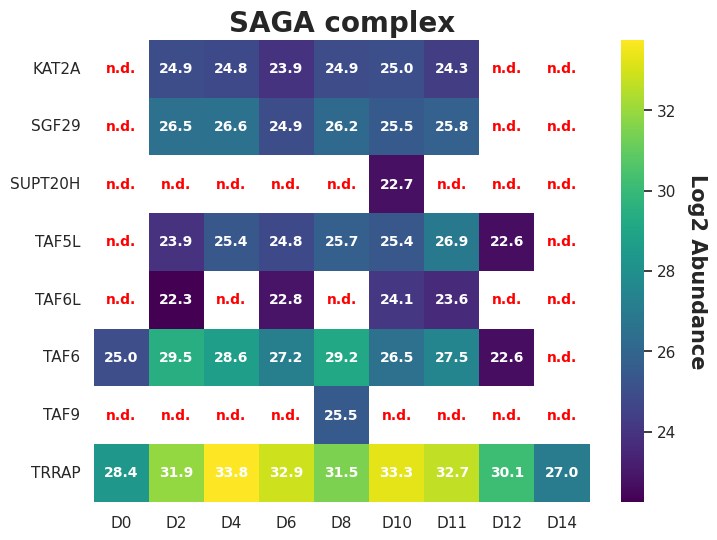

In [ ]:
#@title **Heatmap with no clustering for target protein/gene per experimental group**
#@markdown - Abundance values are normalized using log2 transformation
#@markdown - Missing values are displayed as "n.d" or not detectable

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from IPython.display import display

plt.rcParams['font.family'] = 'DejaVu Sans'

file_path = 'TABLES/median_abundance.csv'
data = pd.read_csv(file_path)

protein_input = widgets.Text(
    value='',
    placeholder='Enter Protein name or Genes separated by commas',
    description='Name:',
    layout=widgets.Layout(width='auto', description_width='initial'),
    style={'description_width': 'initial', 'font_size': '16px'}
)

search_by_input = widgets.Dropdown(
    options=['Protein name', 'Genes'],
    value='Protein name',
    description='Search by:',
    layout=widgets.Layout(width='auto', description_width='initial'),
    style={'description_width': 'initial', 'font_size': '16px'}
)

title_input = widgets.Text(
    value='',
    placeholder='Enter Heatmap Title',
    description='Title:',
    layout=widgets.Layout(width='auto', description_width='initial'),
    style={'description_width': 'initial', 'font_size': '16px'}
)

button = widgets.Button(description="Generate Heatmap", style={'font_weight': 'bold', 'button_color': '#4CAF50', 'font_size': '16px'}, layout=widgets.Layout(
    width='auto',
    height='80px'
))

def generate_heatmap(names, search_by, title):
    desired_order = [name.strip() for name in names.split(',')]

    if search_by == 'Protein name':
        filtered_data = data[data['Protein name'].isin(desired_order)]
        index_column = 'Protein name'
    elif search_by == 'Genes':
        filtered_data = data[data['Genes'].isin(desired_order)]
        index_column = 'Genes'
    else:
        print(f"Invalid search criteria: {search_by}")
        return

    found_names = filtered_data[index_column].tolist()
    not_found_names = [name for name in desired_order if name not in found_names]

    if not found_names:
        print(f"No data found for {search_by}: {names}")
        return

    if not_found_names:
        print(f"The following names were not found in the dataset: {', '.join(not_found_names)}")

    valid_columns = data.columns[3:]
    filtered_data = filtered_data[[index_column] + list(valid_columns)]
    filtered_data.set_index(index_column, inplace=True)
    filtered_data = filtered_data.loc[found_names]
    filtered_data = filtered_data.apply(pd.to_numeric, errors='coerce')
    filtered_data.replace(0, np.nan, inplace=True)

    log2_values = np.log2(filtered_data)

    sns.set(font_scale=1.0)
    plt.figure(figsize=(8, 6))
    heatmap = sns.heatmap(data=log2_values, cmap="viridis", annot=False, fmt=".1f", linewidths=0, linecolor='black', yticklabels=True)

    for i, (name, values) in enumerate(log2_values.iterrows()):
        for j, value in enumerate(values):
            if pd.notna(value):
                plt.text(j + 0.5, i + 0.5, f"{value:.1f}", ha="center", va="center", color="white", fontsize=10, fontweight="bold")
            else:
                plt.text(j + 0.5, i + 0.5, "n.d.", ha="center", va="center", color="red", fontsize=10, fontweight="bold")

    heatmap.set_ylabel("", fontweight='bold', fontsize=20)
    cbar = heatmap.collections[0].colorbar
    cbar.set_label("Log2 Abundance", fontsize=15, labelpad=15, rotation=270, verticalalignment='center', fontweight='bold')
    plt.setp(plt.gca(), facecolor='none')
    plt.title(title, fontsize=20, fontweight='bold')
    file_name = f'PLOTS/Heatmap_no_clustering_experimental_groups_log2_{title.replace(" ", "_")}.tiff'
    plt.savefig(file_name, format='tiff', dpi=300, bbox_inches='tight')

    plt.show()

def on_button_click(b):
    generate_heatmap(protein_input.value, search_by_input.value, title_input.value)

button.on_click(on_button_click)

display(search_by_input, protein_input, title_input, button)

##**Heatmaps for Entire Proteome**

Dropdown(description='Search by:', layout=Layout(width='auto'), options=('Protein name', 'Genes'), style=Descr…

Text(value='', description='Title:', layout=Layout(width='auto'), placeholder='Enter Heatmap Title', style=Des…

Button(description='Generate Heatmap', layout=Layout(height='80px', width='auto'), style=ButtonStyle(button_co…

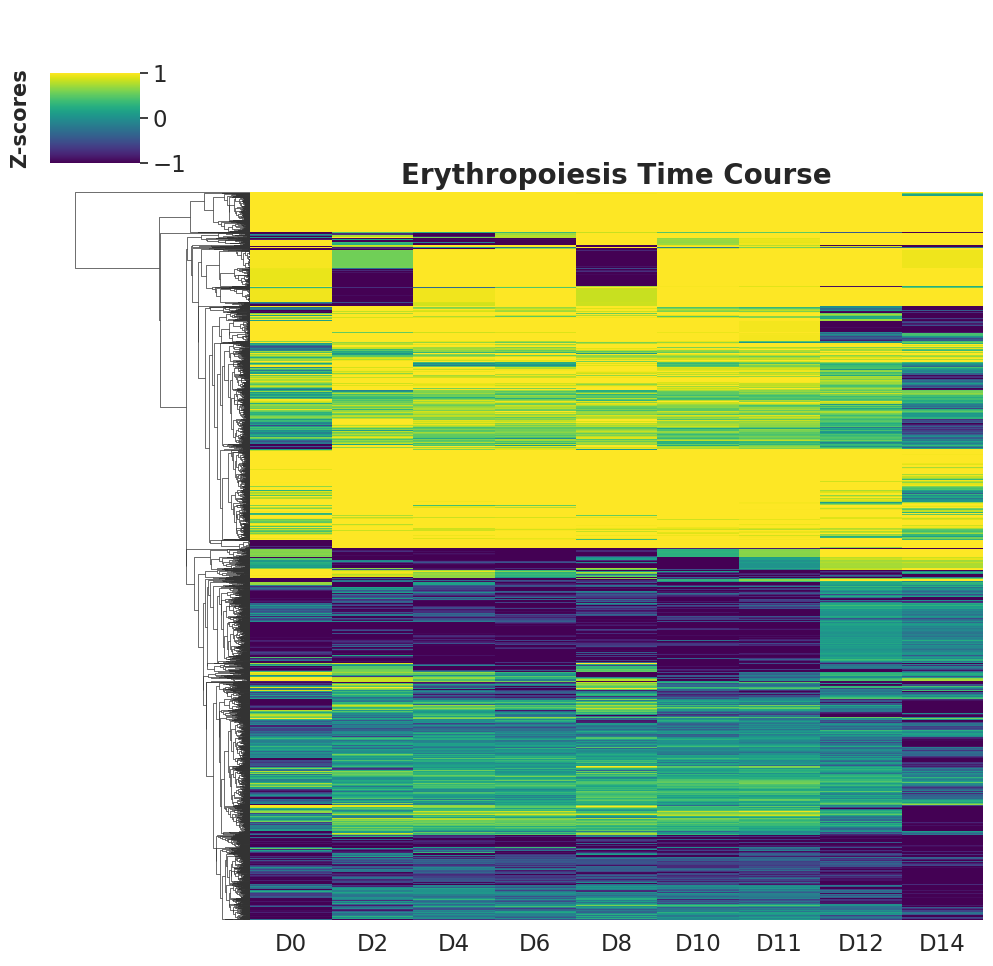

In [ ]:
#@title **Hierarchical clustering heatmap for experimental groups**
#@markdown - Abundance values are subjected to log2 and z-score normalization methods
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from IPython.display import display
import warnings
import re
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    message=re.escape("Clustering large matrix with scipy. Installing `fastcluster` may give better performance.")
)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

plt.rcParams['font.family'] = 'DejaVu Sans'

file_path = 'TABLES/median_abundance.csv'
data = pd.read_csv(file_path)

data = data.drop(columns=['Genes'])
valid_columns = data.columns[2:].tolist()

search_by_input = widgets.Dropdown(
    options=['Protein name', 'Genes'],
    value='Protein name',
    description='Search by:',
    layout=widgets.Layout(width='auto', description_width='initial'),
    style={'description_width': 'initial', 'font_size': '16px'}
)

title_input = widgets.Text(
    value='',
    placeholder='Enter Heatmap Title',
    description='Title:',
    layout=widgets.Layout(width='auto', description_width='initial'),
    style={'description_width': 'initial', 'font_size': '16px'}
)

button = widgets.Button(
    description="Generate Heatmap",
    style={'font_weight': 'bold', 'button_color': '#4CAF50', 'font_size': '16px'},
    layout=widgets.Layout(width='auto', height='80px')
)

def generate_heatmap(search_by, title):
    if search_by == 'Genes':
        data_with_genes = pd.read_csv(file_path)
        filtered_data = data_with_genes[['Genes'] + valid_columns].copy()
        filtered_data.set_index('Genes', inplace=True)
    else:
        filtered_data = data[['Protein name'] + valid_columns].copy()
        filtered_data.set_index('Protein name', inplace=True)

    imputer = IterativeImputer()
    imputed_data = imputer.fit_transform(filtered_data)
    imputed_df = pd.DataFrame(imputed_data, index=filtered_data.index, columns=filtered_data.columns)

    log2_data = imputed_df.apply(lambda col: np.log2(col.where(col > 0)), axis=0)
    z_scores_df = (log2_data - log2_data.mean()) / log2_data.std()
    z_scores_df.replace([np.inf, -np.inf], np.nan, inplace=True)
    z_scores_df.dropna(inplace=True)

    sns.set(font_scale=1.5)
    cmap = sns.color_palette("viridis", as_cmap=True)
    heatmap = sns.clustermap(
        data=z_scores_df,
        cmap=cmap,
        annot=False,
        fmt=".1f",
        linewidths=0,
        linecolor='black',
        yticklabels=False,
        vmin=-1,
        vmax=1,
        col_cluster=False,
        cbar_pos=(0.01, 0.82, 0.09, 0.09)
    )

    heatmap.ax_heatmap.set_ylabel("", fontweight='bold', fontsize=20)
    heatmap.ax_heatmap.set_title(title, fontweight='bold', fontsize=20)

    cbar = heatmap.ax_heatmap.collections[0].colorbar
    cbar.set_label("Z-scores", fontsize=15, labelpad=-120, rotation=90, verticalalignment='center', fontweight='bold')

    plt.show()

def on_button_click(b):
    generate_heatmap(search_by_input.value, title_input.value)

button.on_click(on_button_click)
display(search_by_input)
display(title_input)
display(button)


Dropdown(description='Search by:', layout=Layout(width='auto'), options=('Protein name', 'Genes'), style=Descr…

Text(value='', description='Title:', layout=Layout(width='auto'), placeholder='Enter Heatmap Title', style=Des…

Button(description='Generate Heatmap', layout=Layout(height='80px', width='auto'), style=ButtonStyle(button_co…

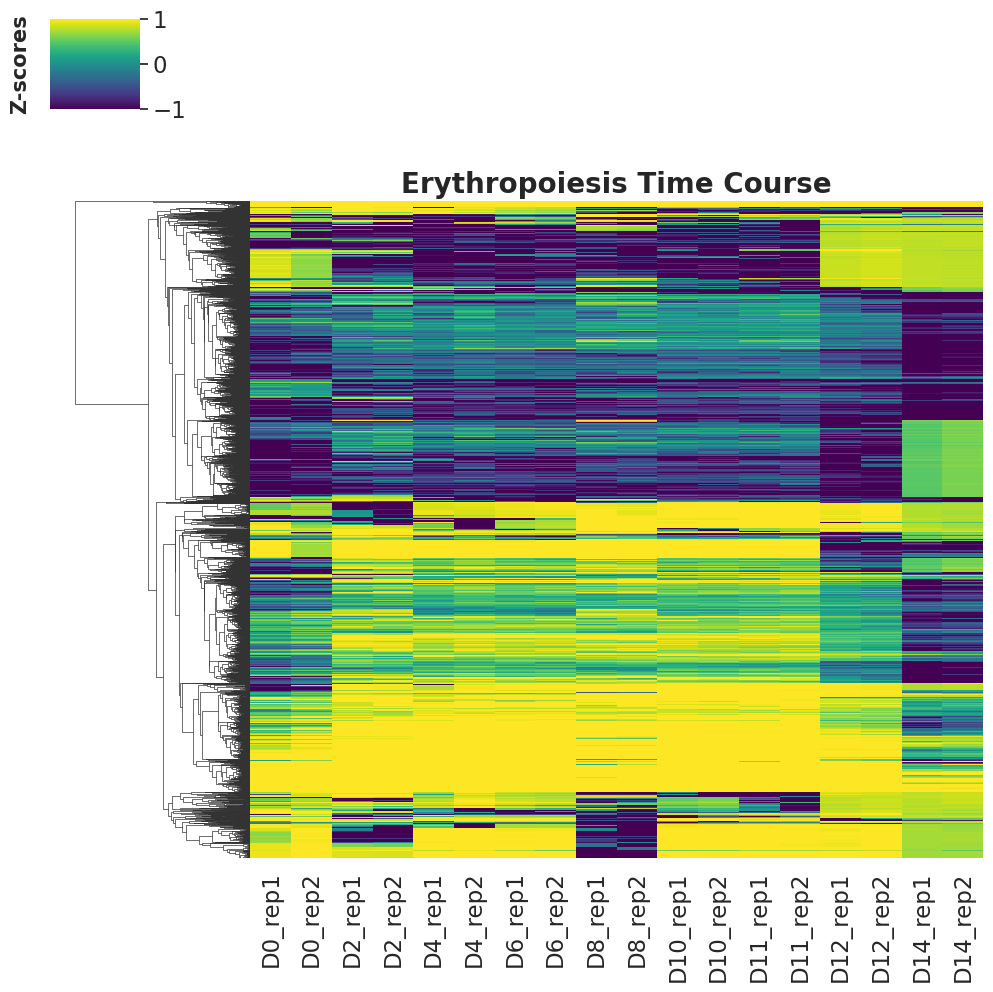

In [ ]:
#@title **Hierarchical clustering heatmap for each sample**
#@markdown - Abundance values are subjected to log2 and z-score normalization methods

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from IPython.display import display
import warnings
import re
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    message=re.escape("Clustering large matrix with scipy. Installing `fastcluster` may give better performance.")
)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

plt.rcParams['font.family'] = 'DejaVu Sans'

file_path = 'TABLES/melted_protein_data_samples.csv'
data = pd.read_csv(file_path)

data = data.drop(columns=['Genes'])
valid_columns = data.columns[2:].tolist()

search_by_input = widgets.Dropdown(
    options=['Protein name', 'Genes'],
    value='Protein name',
    description='Search by:',
    layout=widgets.Layout(width='auto', description_width='initial'),
    style={'description_width': 'initial', 'font_size': '16px'}
)

title_input = widgets.Text(
    value='',
    placeholder='Enter Heatmap Title',
    description='Title:',
    layout=widgets.Layout(width='auto', description_width='initial'),
    style={'description_width': 'initial', 'font_size': '16px'}
)

button = widgets.Button(
    description="Generate Heatmap",
    style={'font_weight': 'bold', 'button_color': '#4CAF50', 'font_size': '16px'},
    layout=widgets.Layout(width='auto', height='80px')
)

def generate_heatmap(search_by, title):
    if search_by == 'Genes':
        data_with_genes = pd.read_csv(file_path)
        filtered_data = data_with_genes[['Genes'] + valid_columns].copy()
        filtered_data.set_index('Genes', inplace=True)
    else:
        filtered_data = data[['Protein name'] + valid_columns].copy()
        filtered_data.set_index('Protein name', inplace=True)

    imputer = IterativeImputer()
    imputed_data = imputer.fit_transform(filtered_data)
    imputed_df = pd.DataFrame(imputed_data, index=filtered_data.index, columns=filtered_data.columns)

    log2_data = imputed_df.apply(lambda col: np.log2(col.where(col > 0)), axis=0)
    z_scores_df = (log2_data - log2_data.mean()) / log2_data.std()
    z_scores_df.replace([np.inf, -np.inf], np.nan, inplace=True)
    z_scores_df.dropna(inplace=True)

    sns.set(font_scale=1.5)
    cmap = sns.color_palette("viridis", as_cmap=True)
    heatmap = sns.clustermap(
        data=z_scores_df,
        cmap=cmap,
        annot=False,
        fmt=".1f",
        linewidths=0,
        linecolor='black',
        yticklabels=False,
        vmin=-1,
        vmax=1,
        col_cluster=False,
        cbar_pos=(0.01, 0.9, 0.09, 0.09)
    )

    heatmap.ax_heatmap.set_ylabel("", fontweight='bold', fontsize=20)
    heatmap.ax_heatmap.set_title(title, fontweight='bold', fontsize=20)

    cbar = heatmap.ax_heatmap.collections[0].colorbar
    cbar.set_label("Z-scores", fontsize=15, labelpad=-120, rotation=90, verticalalignment='center', fontweight='bold')

    plt.savefig('PLOTS/Heatmap_total_proteome_samples.tiff', format='tiff', dpi=300, bbox_inches='tight')
    plt.show()

def on_button_click(b):
    generate_heatmap(search_by_input.value, title_input.value)

button.on_click(on_button_click)
display(search_by_input)
display(title_input)
display(button)

